## Import

In [1]:
from sklearn.ensemble import RandomForestRegressor

import joblib
import numpy as np

In [2]:
from physics.Iso_data_handler import Iso_data_handler
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator

In [3]:
pre_path = "../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/final_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/final_models/"
path_to_models = 'model/final_models/'
tag = "Base"
output_parameters = ["mass", "radius"]
categories_name = ["label"]

## Data preparation

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


In [5]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})

In [6]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)
print(categories_train.shape, categories_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)
(241272, 1) (80424, 1)


## Getting the final evaluations

### Fine-tuned parameters


Base train data :
Training the model...
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.952
  RVE :  0.9999377244849484
  RMSE :  0.024135435515815595
  MAE :  0.006407453086629332
  MedAE :  0.000579999999985481
  CORR :  0.99996900805314
  MAX_ER :  0.8136549999999598
  Percentiles : 
    75th percentile :  0.0033624999999986582
    90th percentile :  0.01498574999999262
    95th percentile :  0.03190262499998126
    99th percentile :  0.08962665000005827

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999564096566891
  RMSE :  0.02188458953434638
  MAE :  0.008158292098256798
  MedAE :  0.0016024999999770806
  CORR :  0.9999782318846071
  MAX_ER :  0.40867499999998635
  Percentiles : 
    75th percentile :  0.008289999999984143
    90th percentile :  0.021579000000002936
    95th percentile :  0.03308062499999701
    99th percentile :  0.08528134999999613

mass results

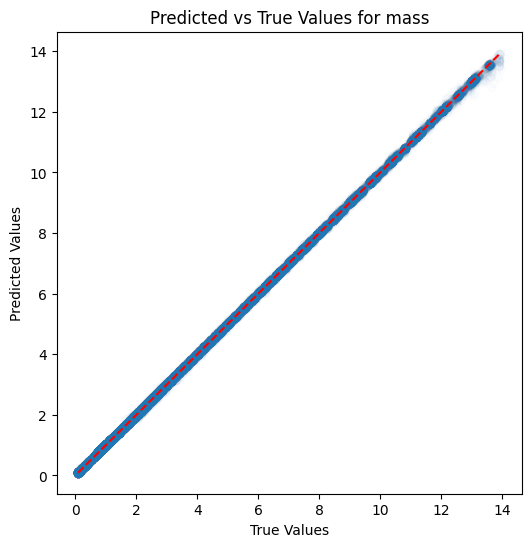

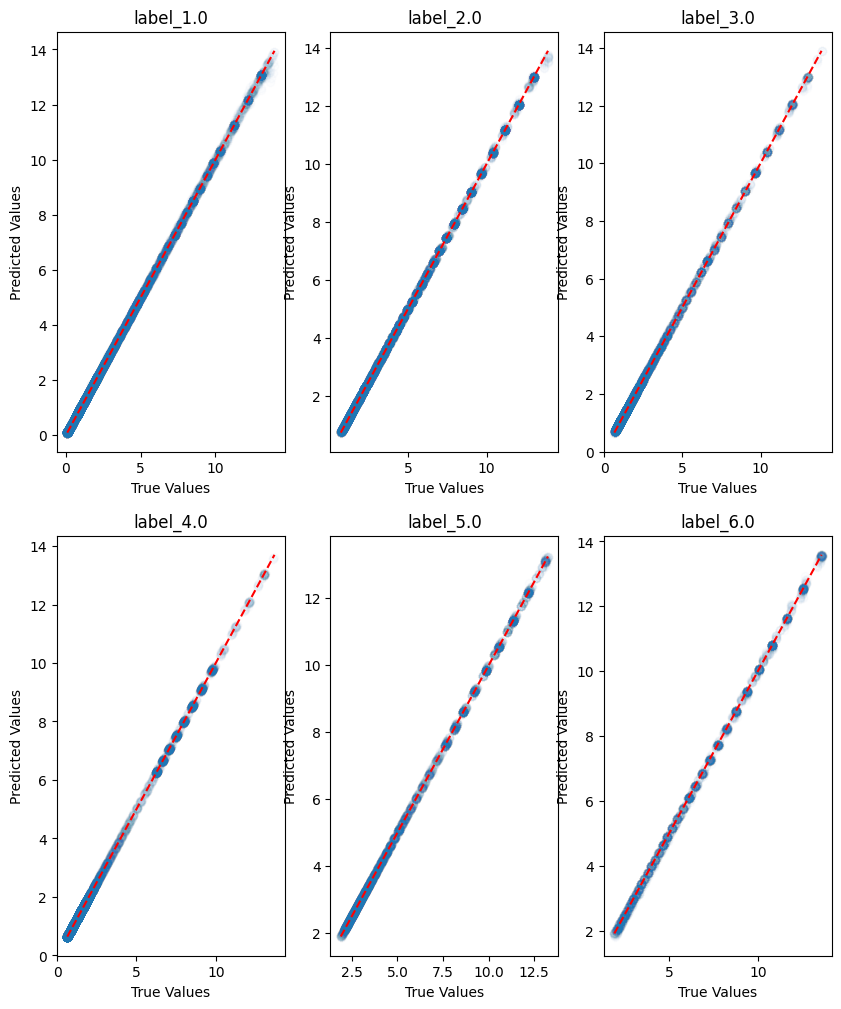

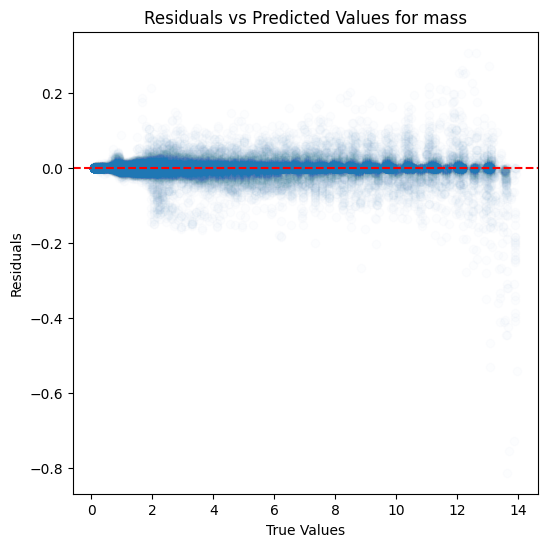

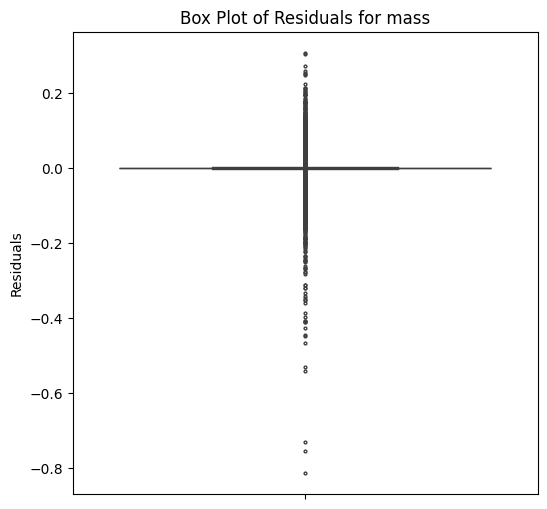

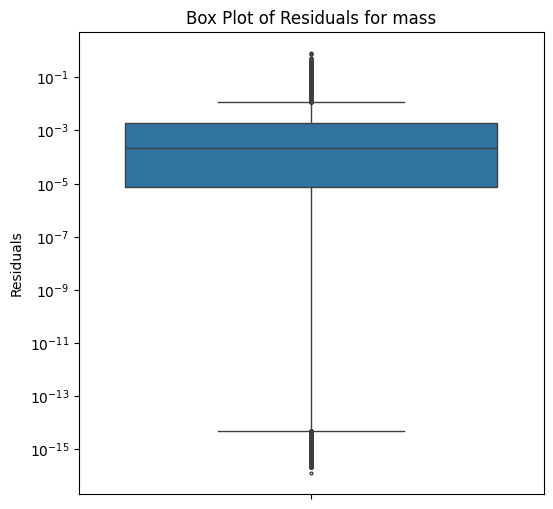

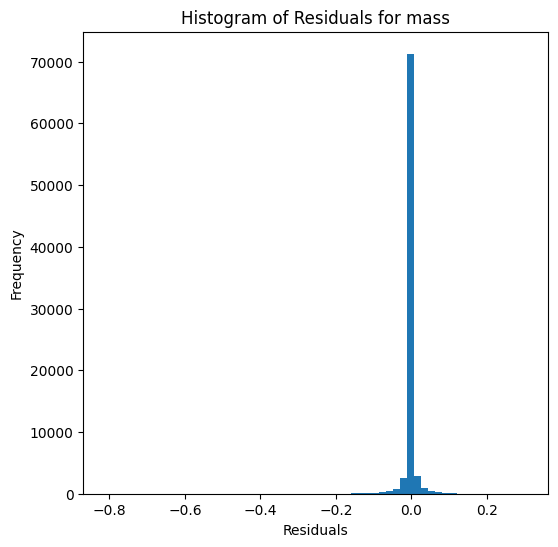

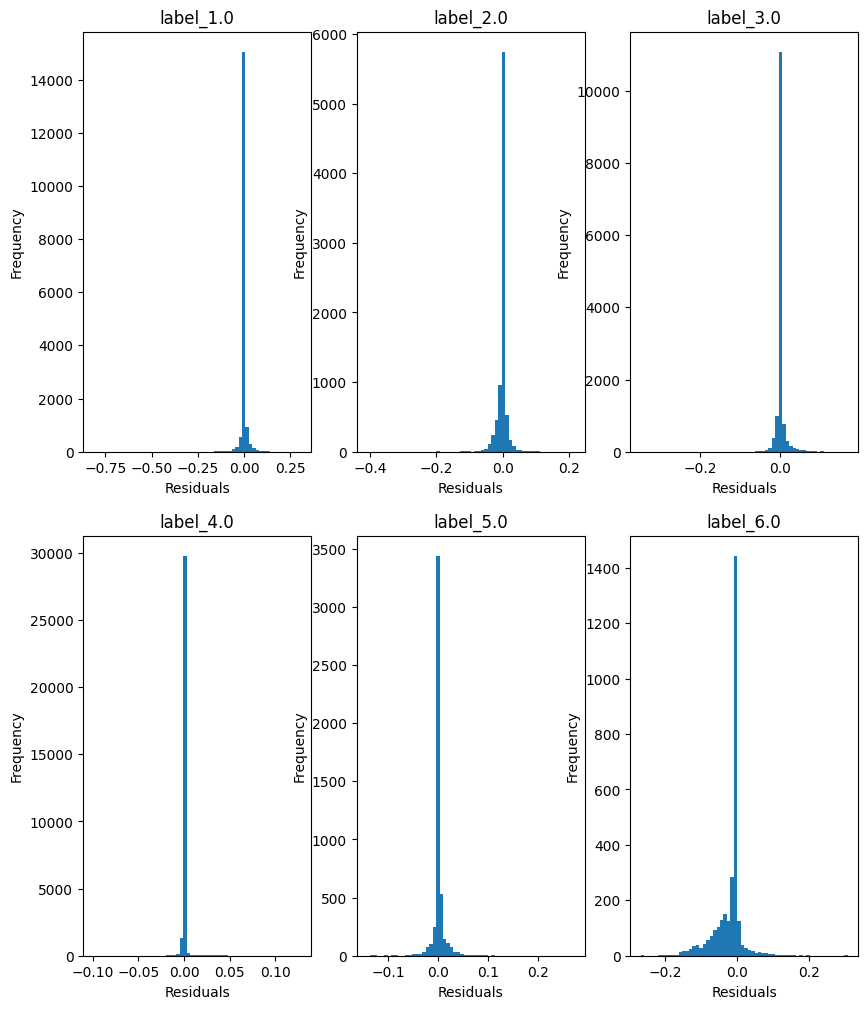

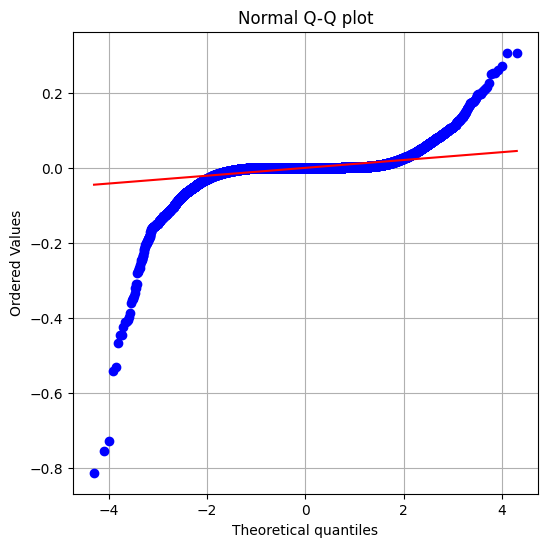

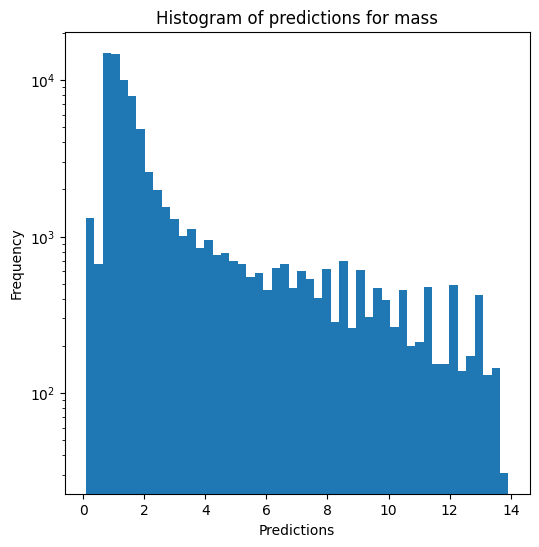

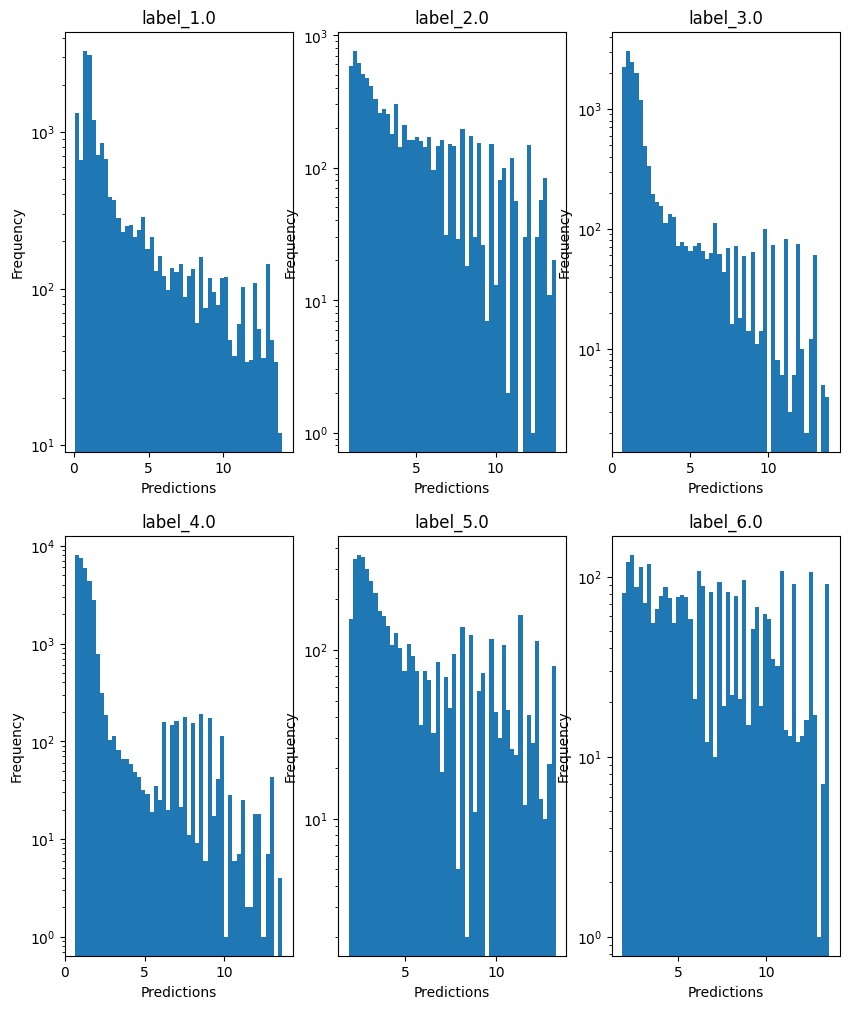

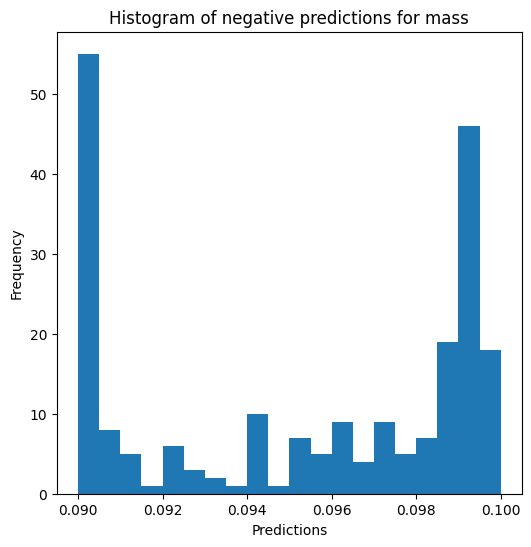


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.9999563372992015
  RMSE :  0.002442979767361863
  MAE :  0.001030336568372148
  MedAE :  0.00023935995017568268
  CORR :  0.9999782748947996
  MAX_ER :  0.04134340376933565
  Percentiles : 
    75th percentile :  0.0009477412371259042
    90th percentile :  0.0028415040198171786
    95th percentile :  0.004730549012796308
    99th percentile :  0.010699921973066996

radius results for the label category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.9998809405378958
  RMSE :  0.005973492958727178
  MAE :  0.002368666733435215
  MedAE :  0.0006011189776981007
  CORR :  0.9999483769959712
  MAX_ER :  0.12145572325947285
  Percentiles : 
    75th percentile :  0.0023098536289826166
    90th percentile :  0.006203159352891607
    95th percentile :  0.010274304137749492
    99th percentile :  0.02375653794399153

radius result

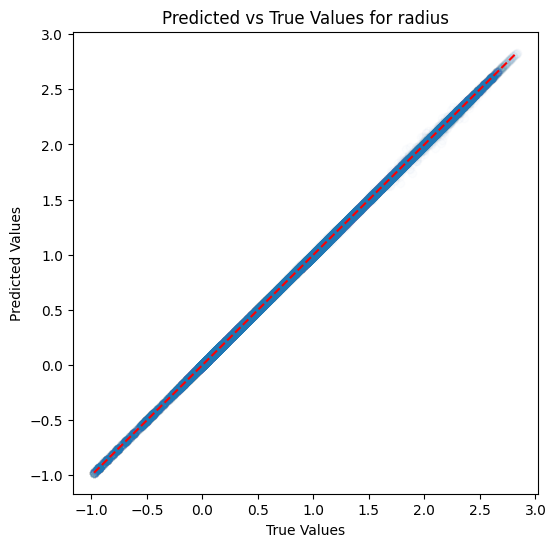

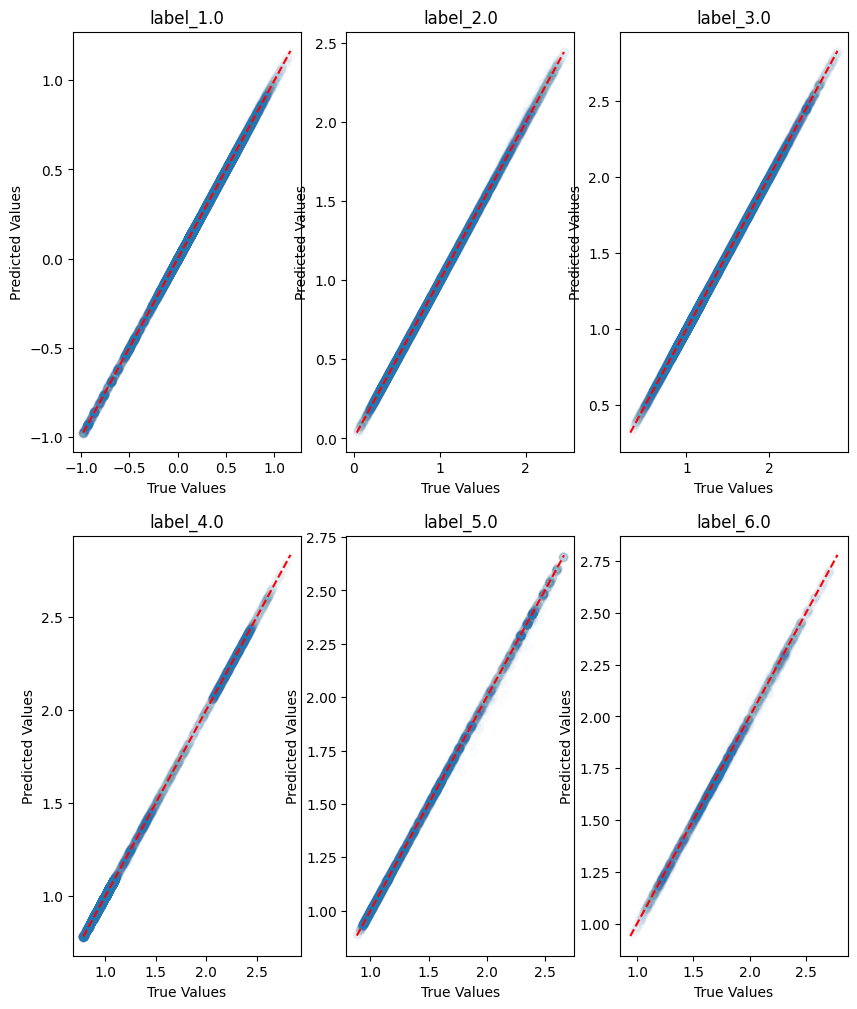

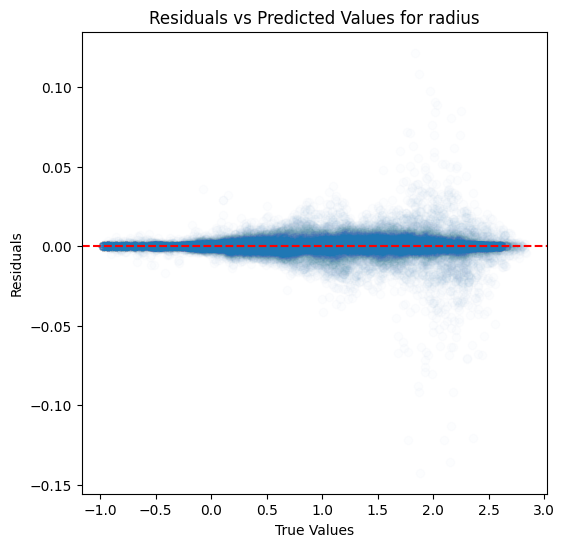

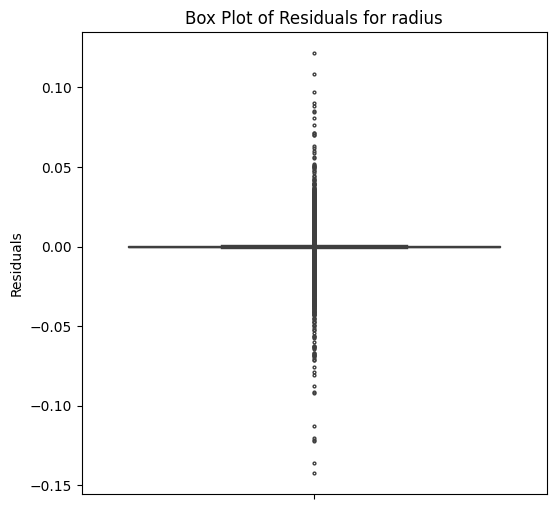

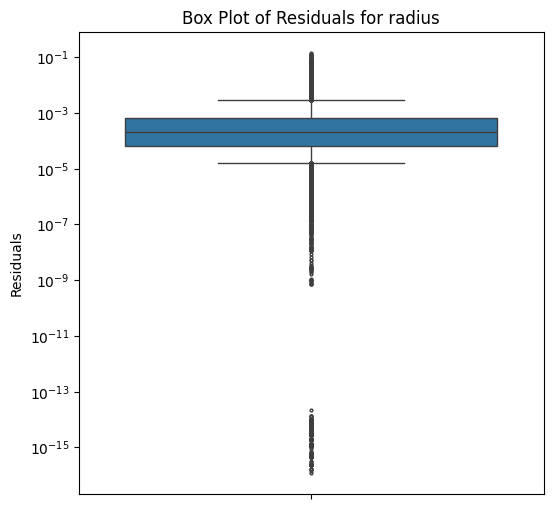

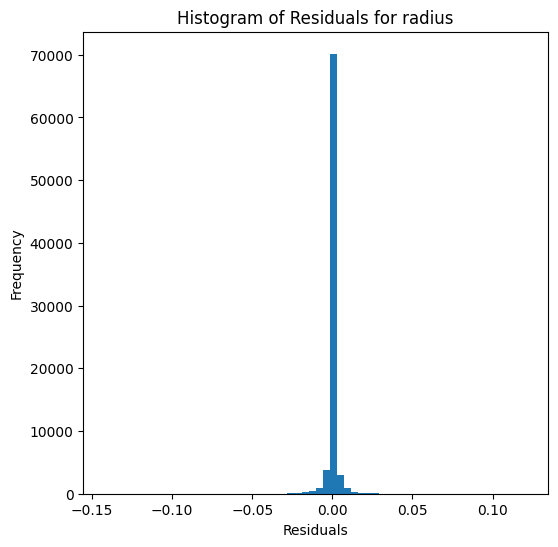

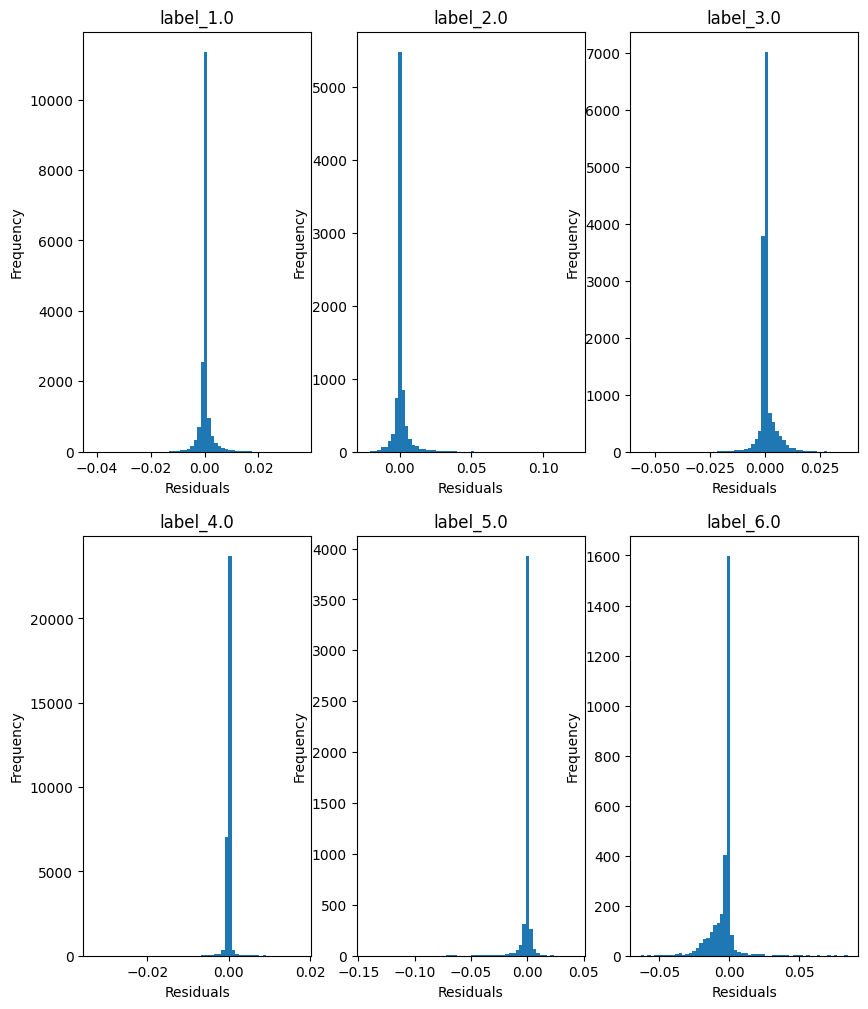

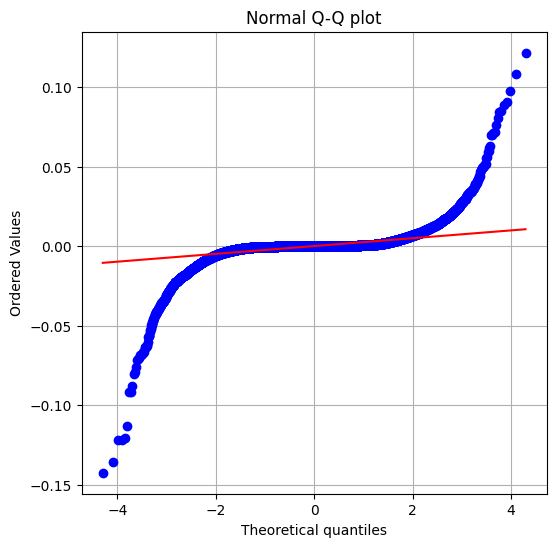

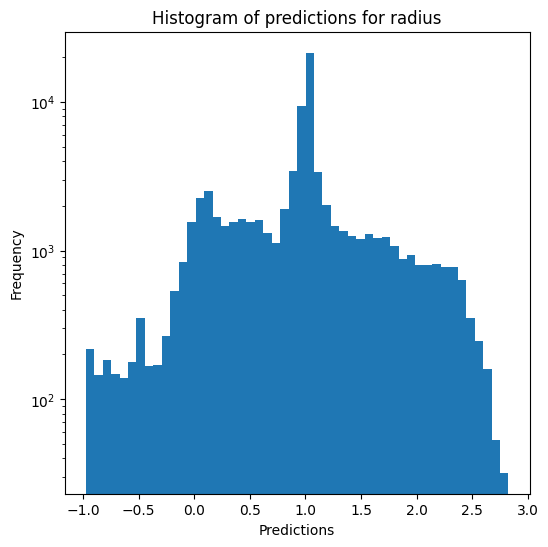

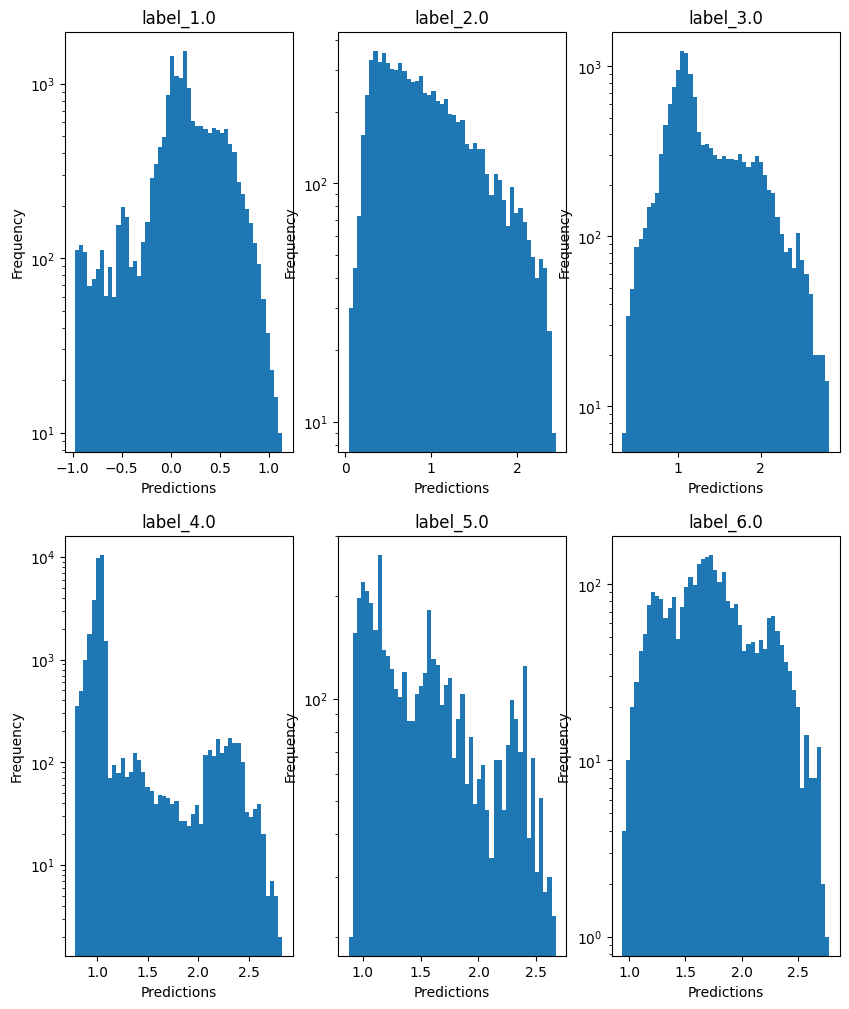

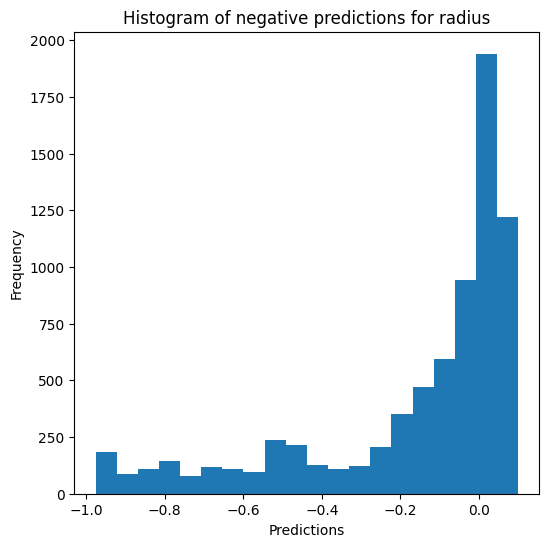

Saving predictions and results...


In [7]:
best_params_RF = {'n_jobs':10, 'n_estimators': 400, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_RF)

### Testing other parameters (not used here)


mass_smaller_14 train data :
Training the model...
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999981896729906 - 13.99946885003588
  RVE :  0.9999467718770866
  RMSE :  0.02411463024372743
  MAE :  0.0067364414796584554
  MedAE :  0.001866533008964666
  CORR :  0.9999735195382853
  MAX_ER :  1.5450187963737836
  Percentiles : 
    75th percentile :  0.0057613689784268285
    90th percentile :  0.014781809899707189
    95th percentile :  0.025170160171211518
    99th percentile :  0.07339691505834839

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 13.92718523912214
  RVE :  0.9999680795620336
  RMSE :  0.018494855707891358
  MAE :  0.008995234461647598
  MedAE :  0.004336623453316646
  CORR :  0.9999841001464754
  MAX_ER :  0.4436294750024494
  Percentiles : 
    75th percentile :  0.009699899003265067
    90th percentile :  0.020362106796630156
    95th percenti

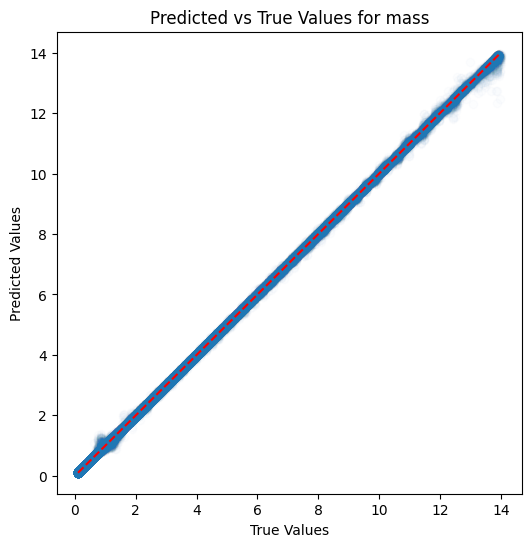

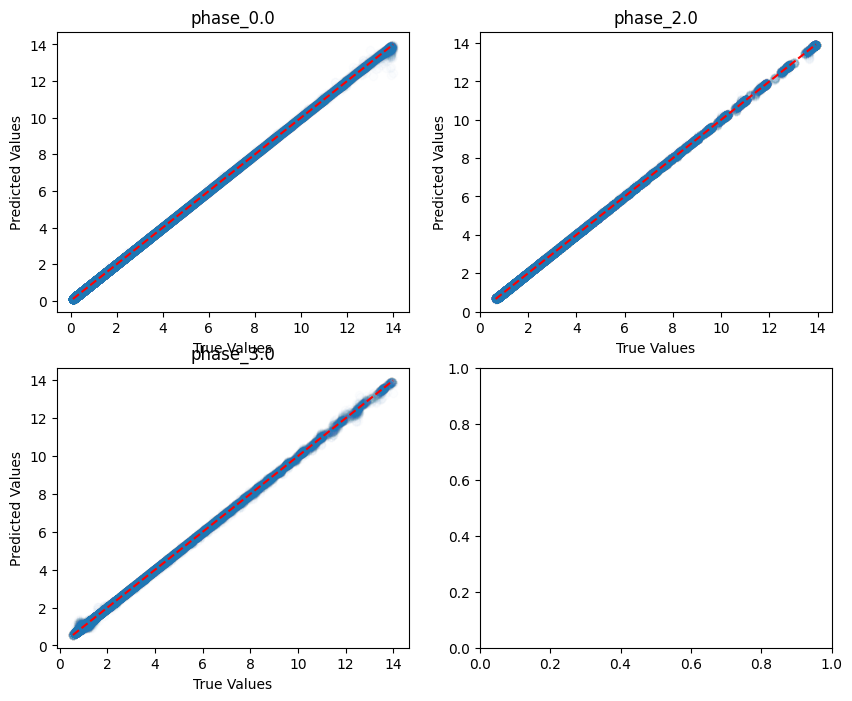

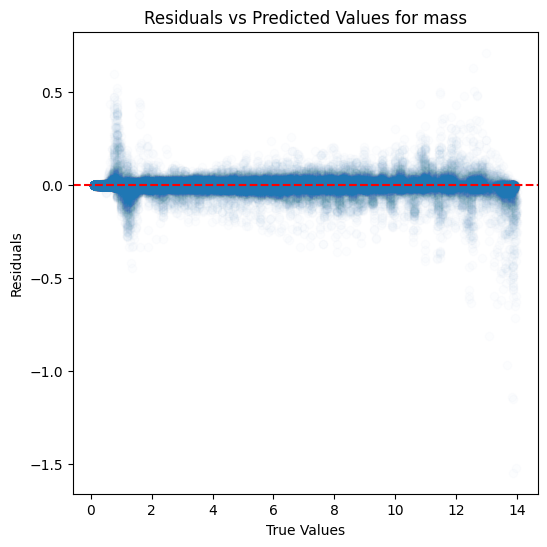

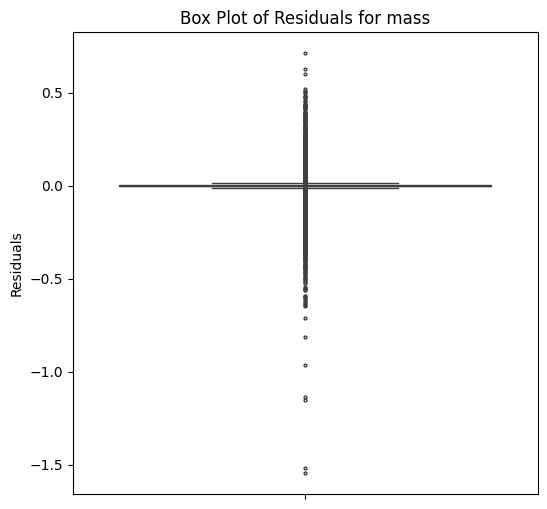

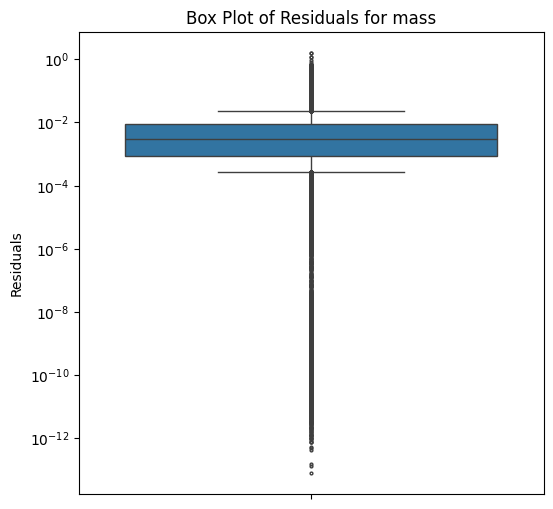

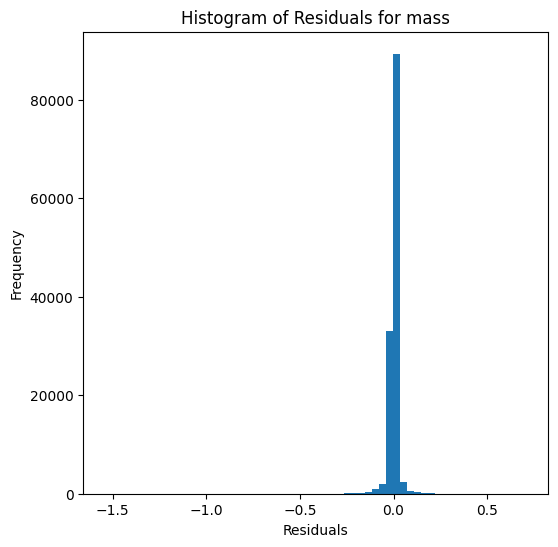

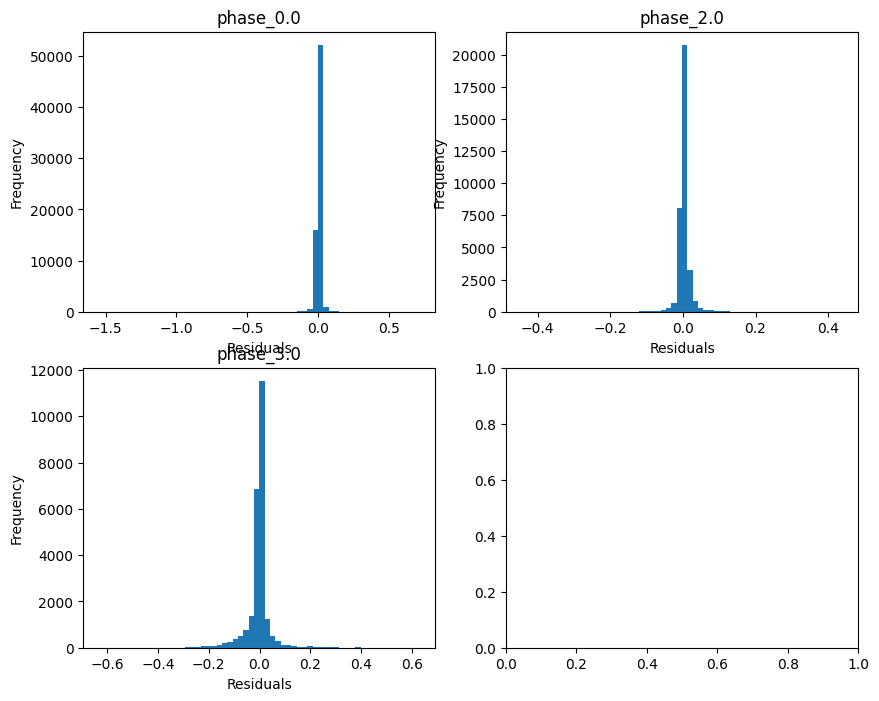

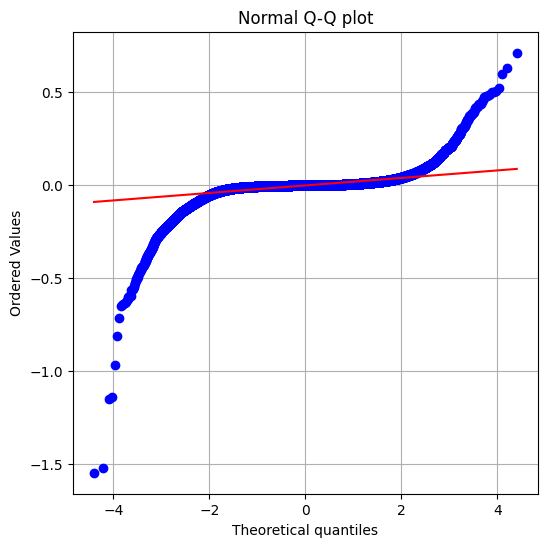

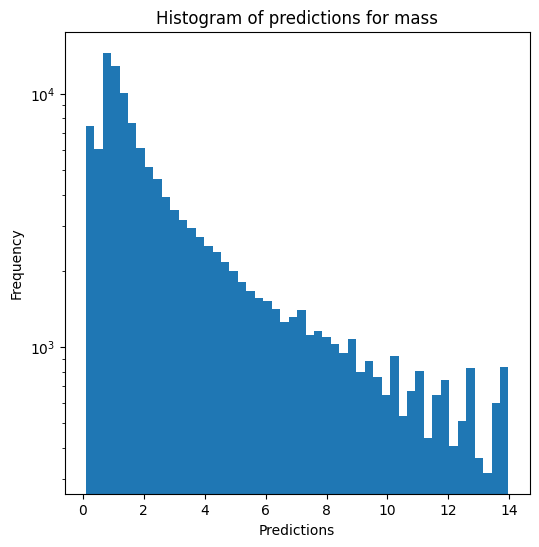

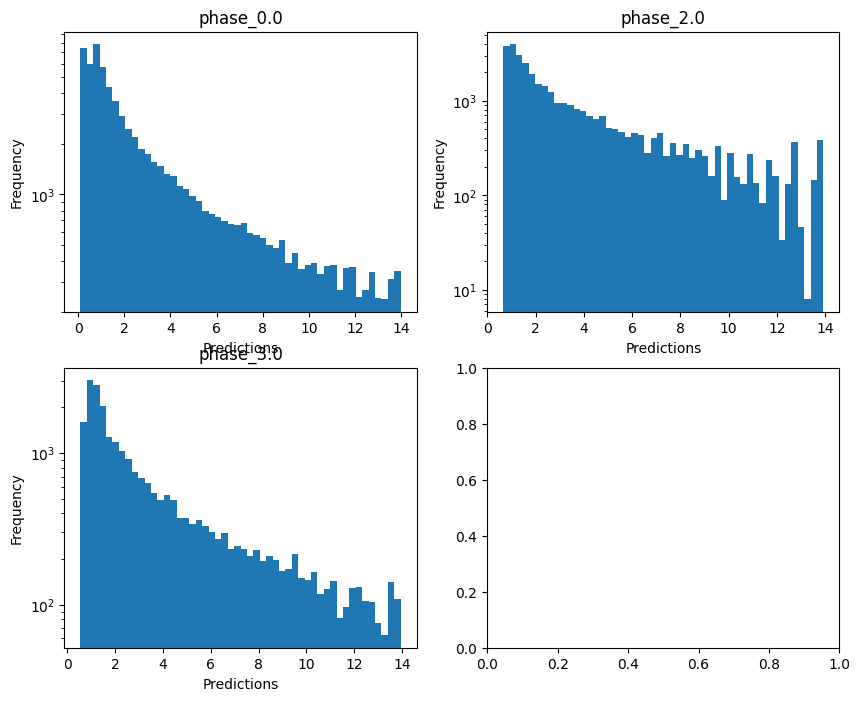


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 3.0827540579576227
  RVE :  0.9999853488212626
  RMSE :  0.0016245838368522901
  MAE :  0.0009318375099382238
  MedAE :  0.0005021859552321595
  CORR :  0.9999926923563865
  MAX_ER :  0.03977896843788664
  Percentiles : 
    75th percentile :  0.001119975600288009
    90th percentile :  0.0022736961614332253
    95th percentile :  0.003289517804292349
    99th percentile :  0.006009078153865969

radius results for the phase category with a value of 2.0
  value range :  0.0946930588223481 - 2.900376516729969
  RVE :  0.9999552960269019
  RMSE :  0.003288139903569789
  MAE :  0.002305511784380038
  MedAE :  0.0016070491604933679
  CORR :  0.9999798895409828
  MAX_ER :  0.028851461016875746
  Percentiles : 
    75th percentile :  0.0030673824082536882
    90th percentile :  0.005278972243063599
    95th percentile :  0.007062545158985466
    99th percentile :  0.011024923634535186

radius res

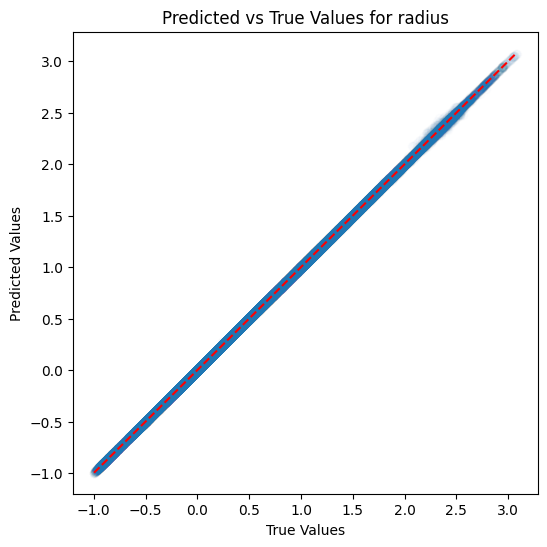

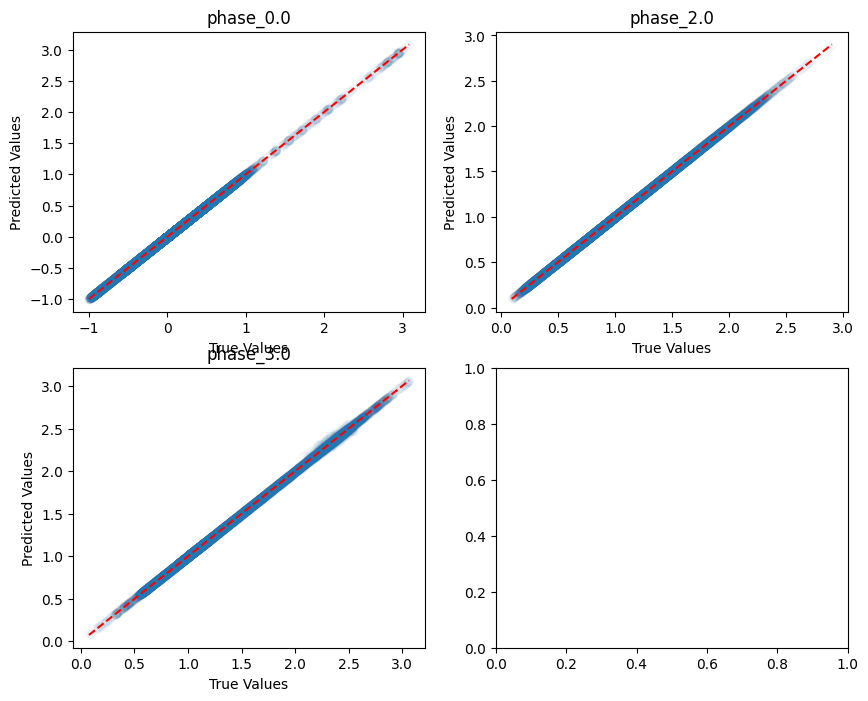

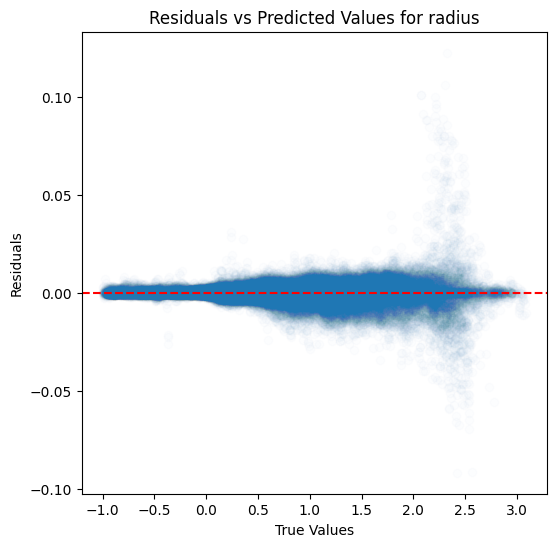

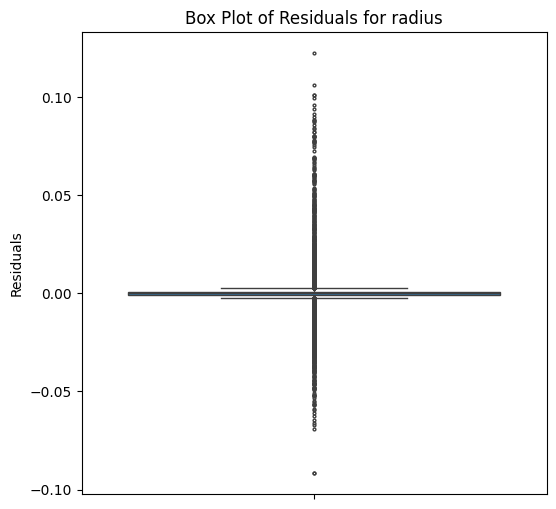

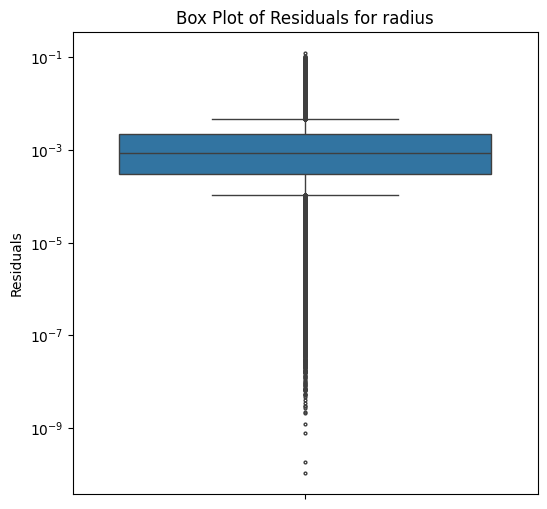

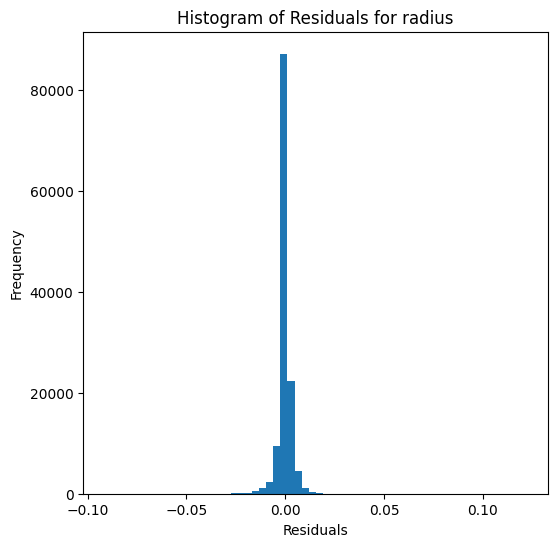

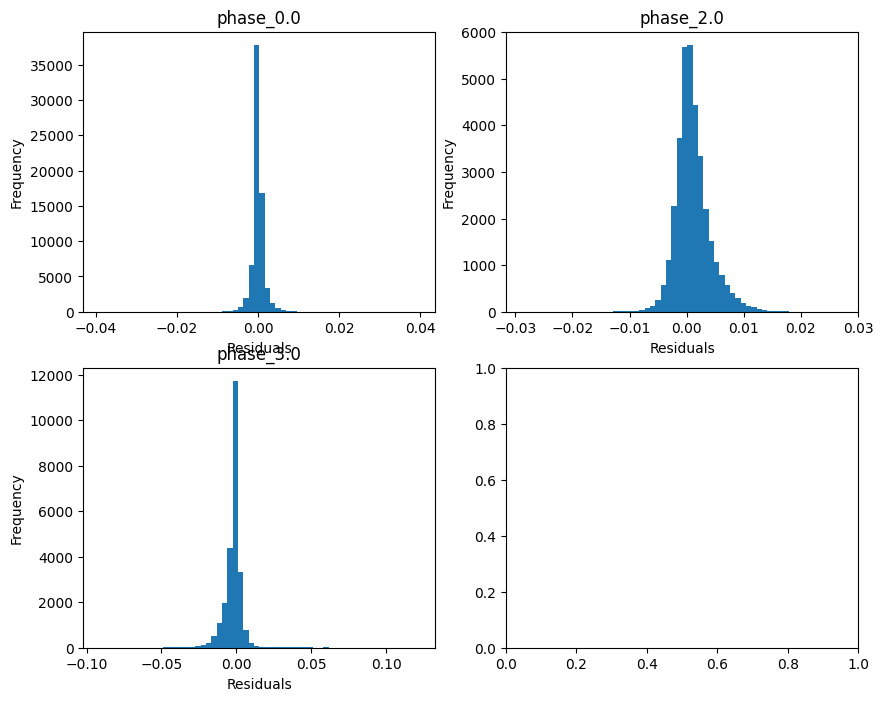

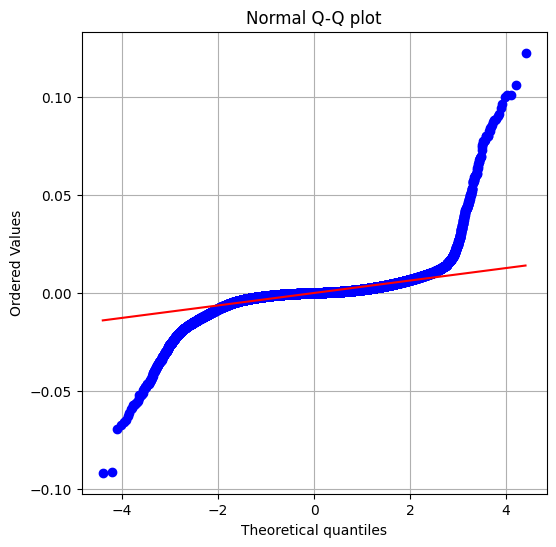

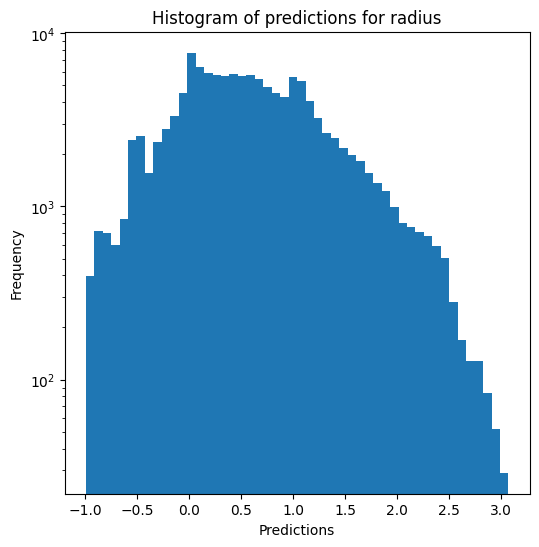

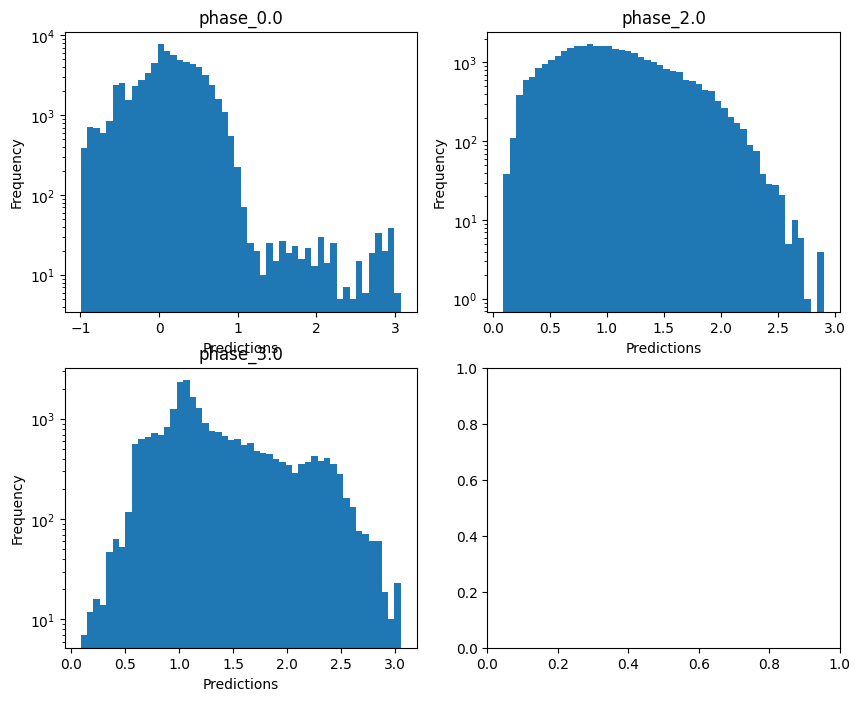

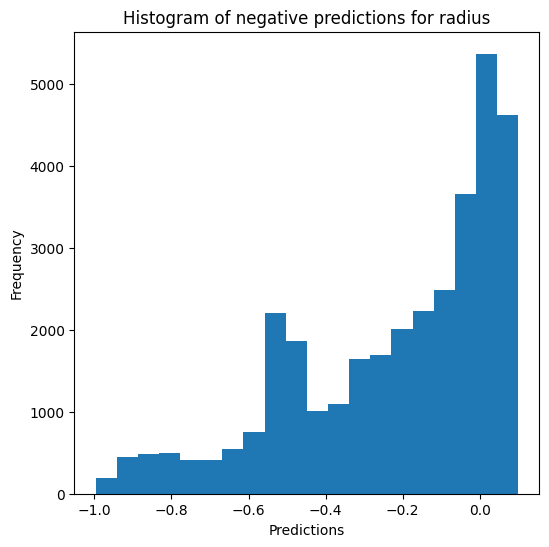

In [8]:
best_params_RF = {'n_jobs':10, 'n_estimators': 500, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=False, show=True, **best_params_RF)


mass_smaller_14 train data :
Training the model...
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999981896729906 - 13.99946885003588
  RVE :  0.9999465561852118
  RMSE :  0.024163588757793574
  MAE :  0.0066063626493922546
  MedAE :  0.0018163574011716976
  CORR :  0.9999733964239901
  MAX_ER :  1.610785056976109
  Percentiles : 
    75th percentile :  0.005562293472129554
    90th percentile :  0.014490083214730732
    95th percentile :  0.024665634834096263
    99th percentile :  0.07249141843988675

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 13.92718523912214
  RVE :  0.9999690610786282
  RMSE :  0.018217399288522142
  MAE :  0.008884158214719228
  MedAE :  0.004269911010943983
  CORR :  0.9999845974870841
  MAX_ER :  0.4372739940263024
  Percentiles : 
    75th percentile :  0.009661922836334047
    90th percentile :  0.02007340238107416
    95th percentil

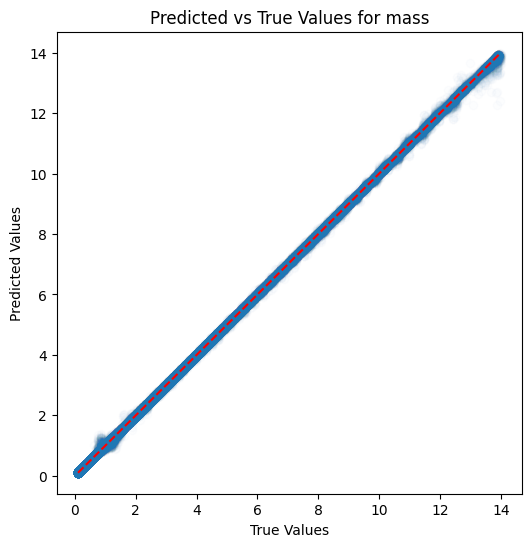

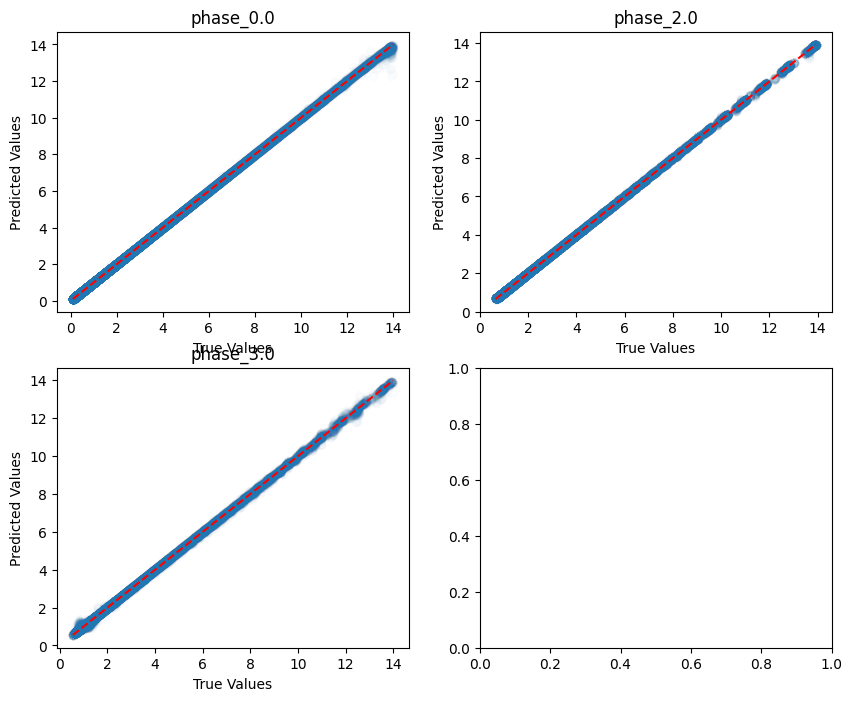

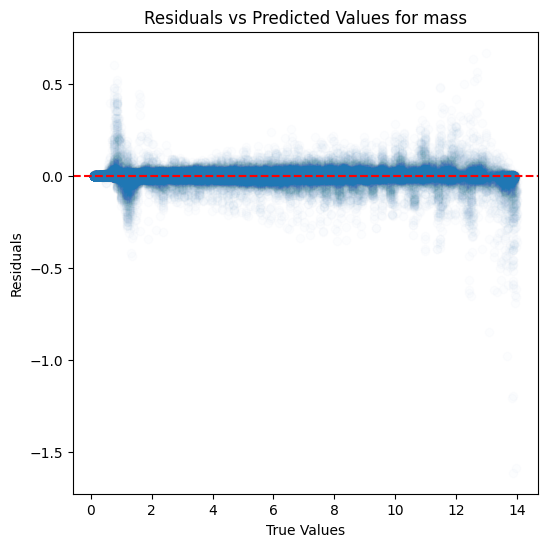

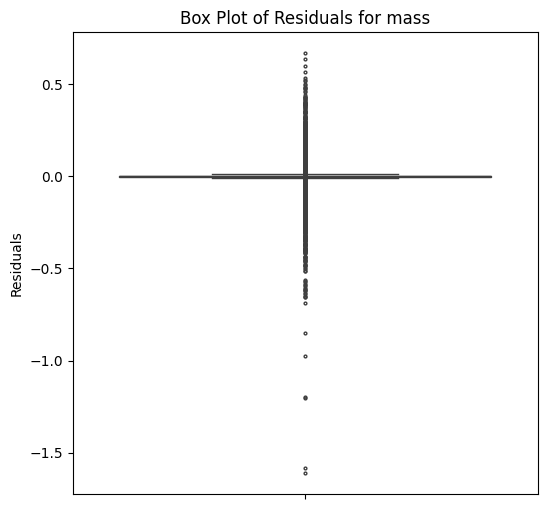

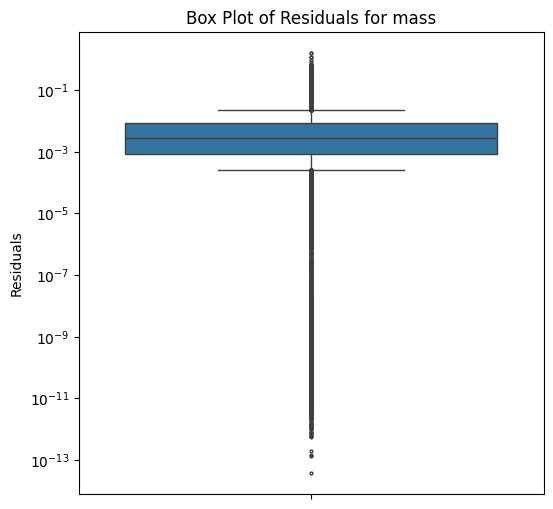

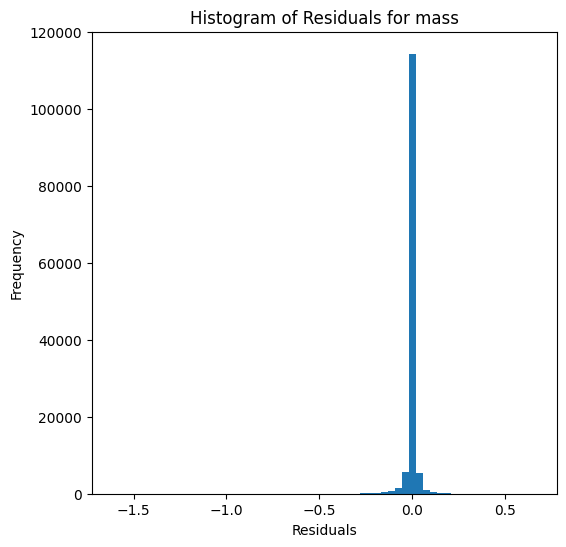

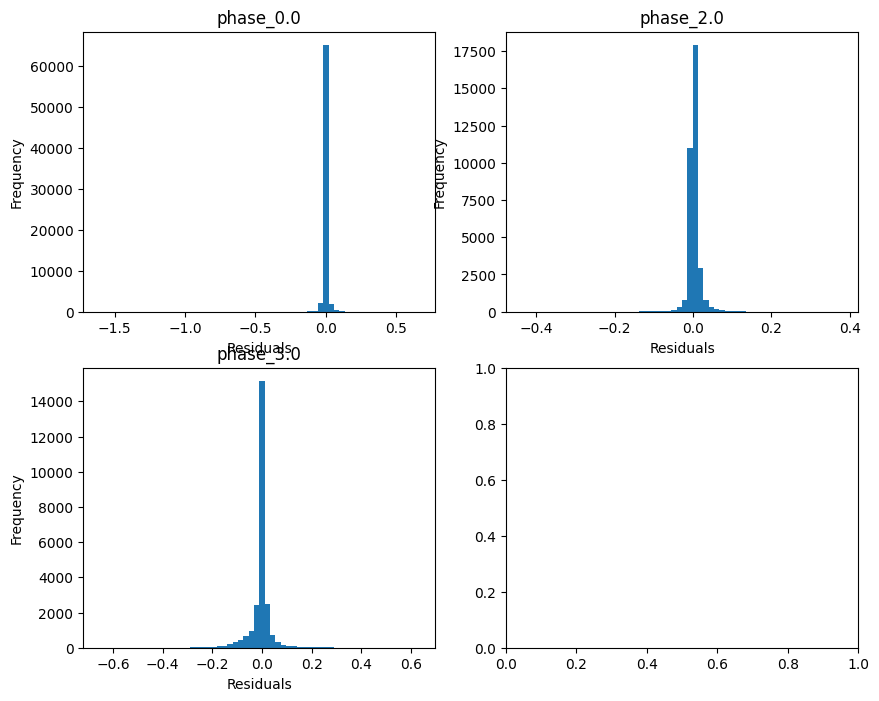

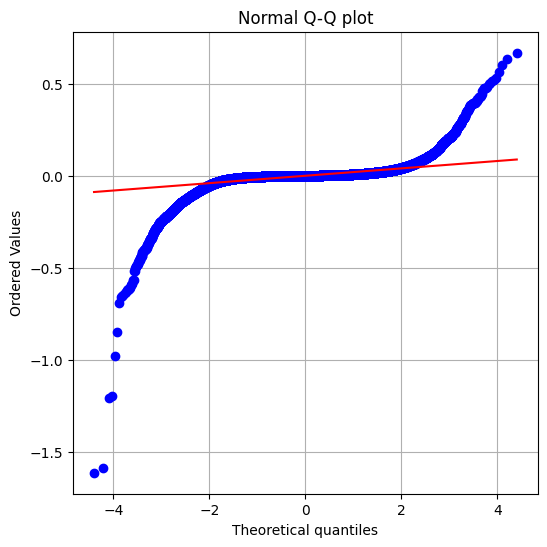

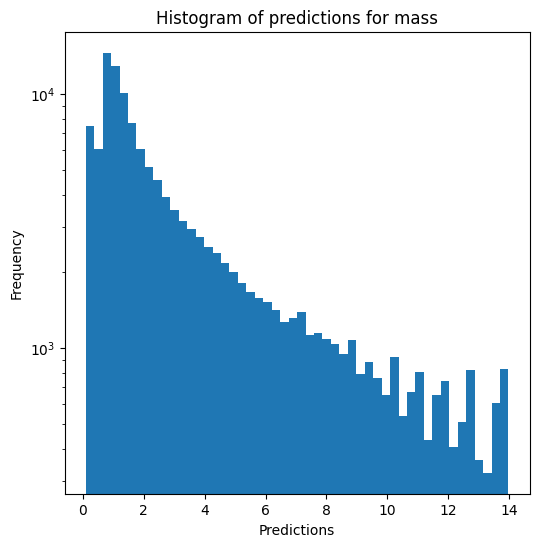

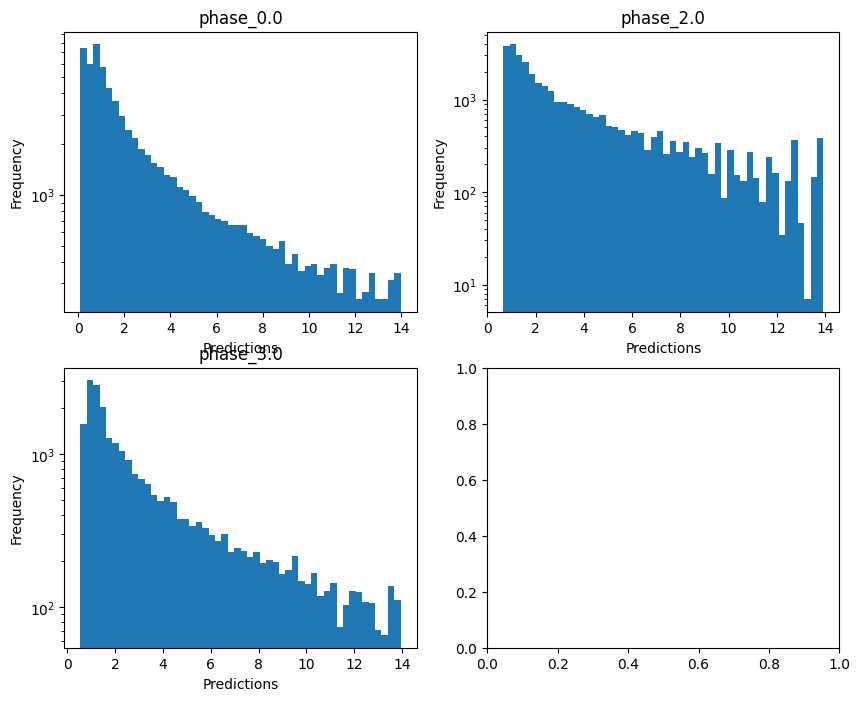


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 3.0827540579576227
  RVE :  0.9999859784775073
  RMSE :  0.0015893347438286785
  MAE :  0.000904662844830368
  MedAE :  0.0004832385409018758
  CORR :  0.9999930051351114
  MAX_ER :  0.04033011340180748
  Percentiles : 
    75th percentile :  0.001083206711148088
    90th percentile :  0.0021962581003204256
    95th percentile :  0.0032117857934924115
    99th percentile :  0.005888722871196857

radius results for the phase category with a value of 2.0
  value range :  0.0946930588223481 - 2.900376516729969
  RVE :  0.9999566150019567
  RMSE :  0.0032471438612764517
  MAE :  0.0022670722517985015
  MedAE :  0.0015593893138588777
  CORR :  0.999980601282633
  MAX_ER :  0.029186952495252605
  Percentiles : 
    75th percentile :  0.002999079039505609
    90th percentile :  0.005234536761443409
    95th percentile :  0.006992721223855288
    99th percentile :  0.010975181023555285

radius res

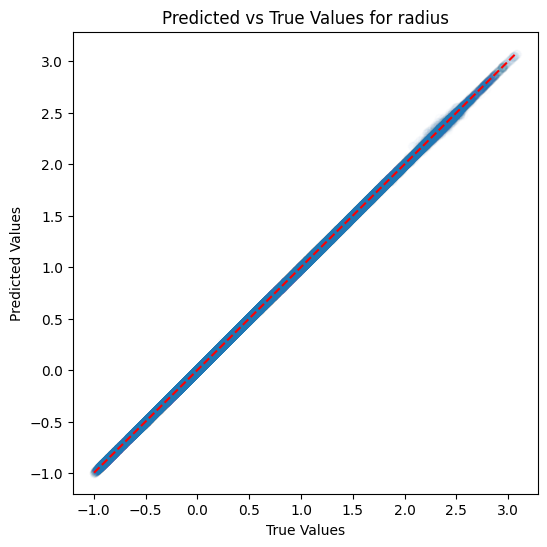

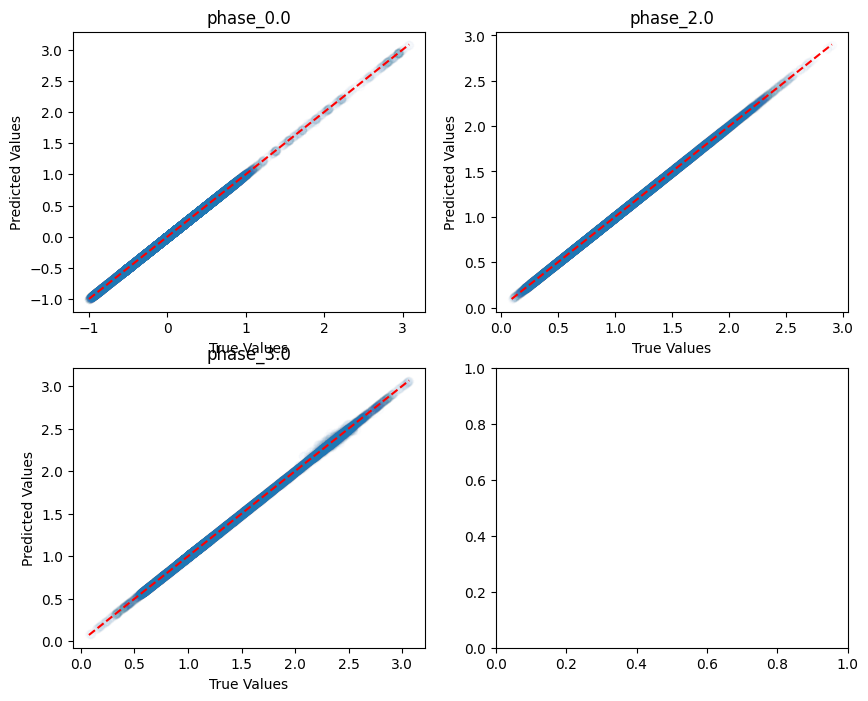

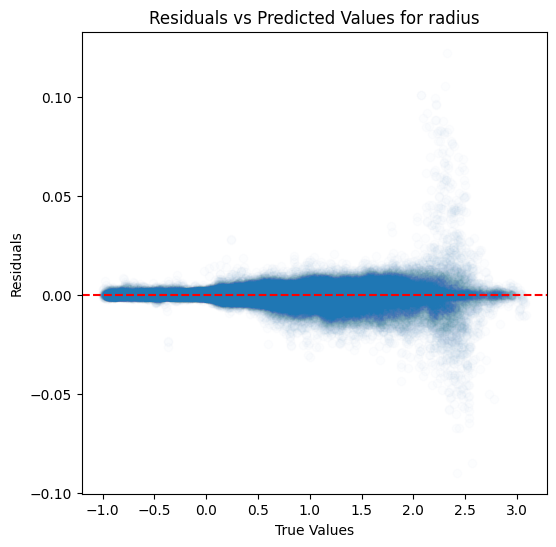

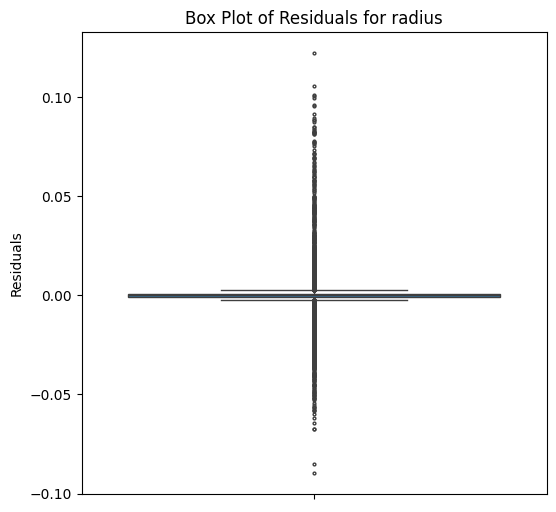

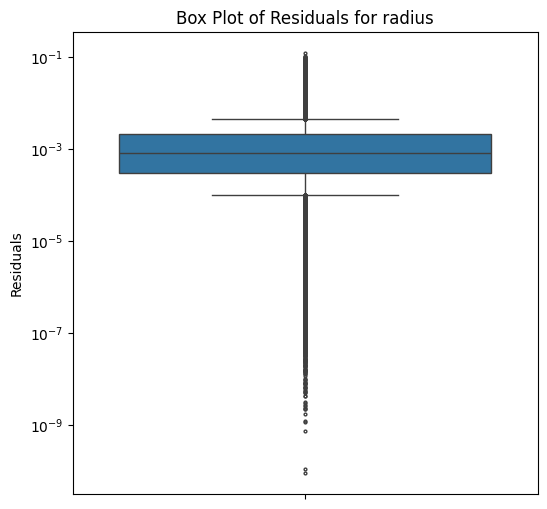

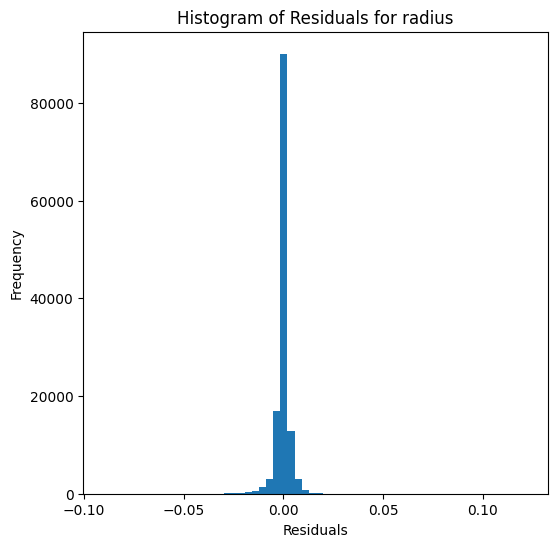

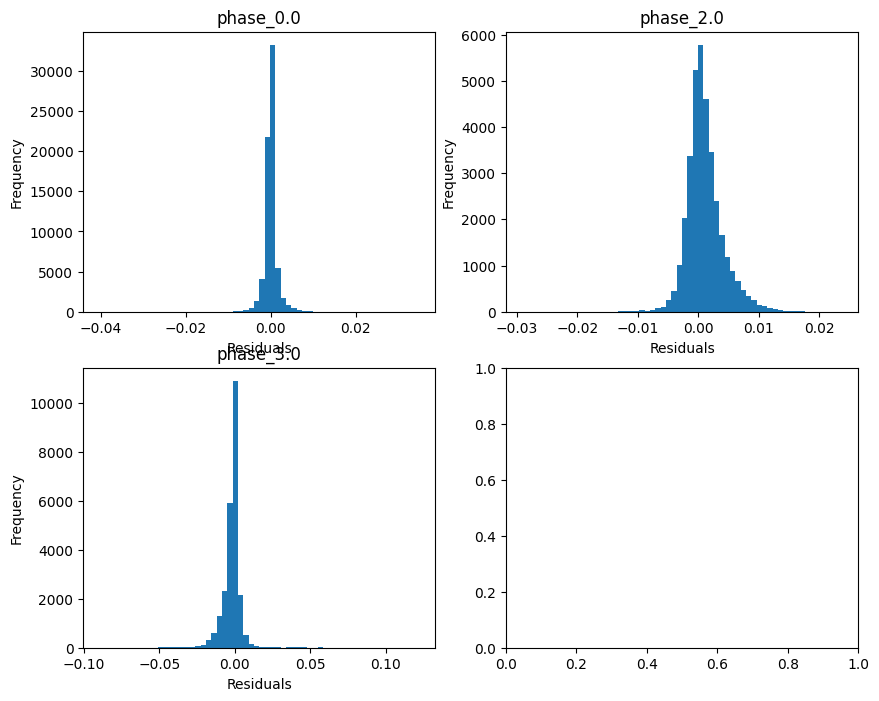

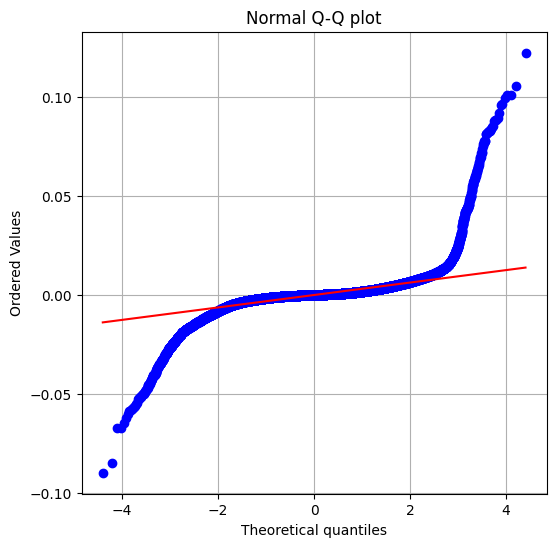

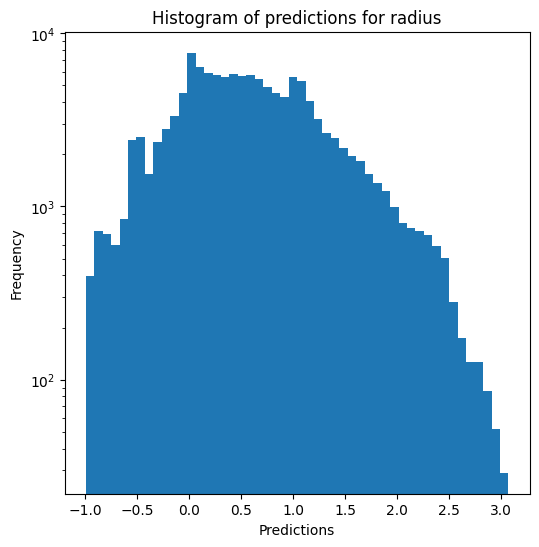

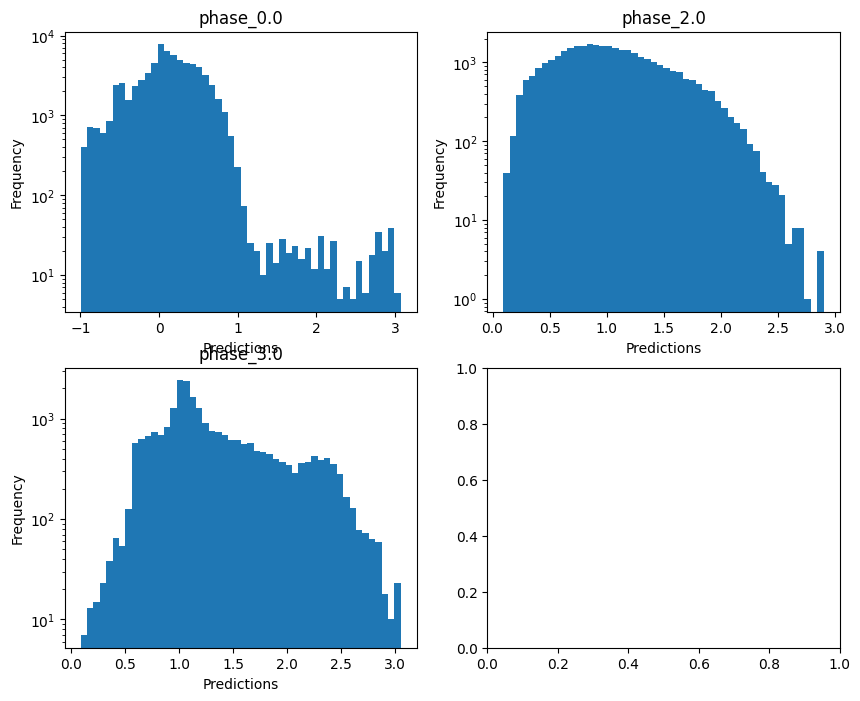

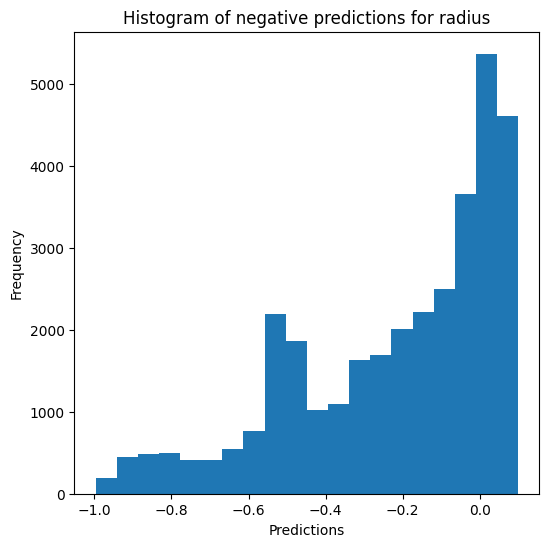

In [7]:
best_params_RF = {'n_jobs':10, 'n_estimators': 1000, 'criterion': 'squared_error', 'max_depth': 75, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=False, show=True, **best_params_RF)


mass_smaller_14 train data :
Training the model...
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999981896729906 - 13.99946885003588
  RVE :  0.998909861110269
  RMSE :  0.10914413770401203
  MAE :  0.06420979769216034
  MedAE :  0.03886993108827108
  CORR :  0.9994744252967012
  MAX_ER :  2.479105376460634
  Percentiles : 
    75th percentile :  0.0795573232549267
    90th percentile :  0.14313072952065142
    95th percentile :  0.19810403904561455
    99th percentile :  0.4031896326073693

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 13.92718523912214
  RVE :  0.9989546982645169
  RMSE :  0.10578618266153884
  MAE :  0.07746732459505001
  MedAE :  0.05955876388404091
  CORR :  0.9994782358842624
  MAX_ER :  1.1682599659860404
  Percentiles : 
    75th percentile :  0.11066435662795593
    90th percentile :  0.16680751554063541
    95th percentile :  0.20280092

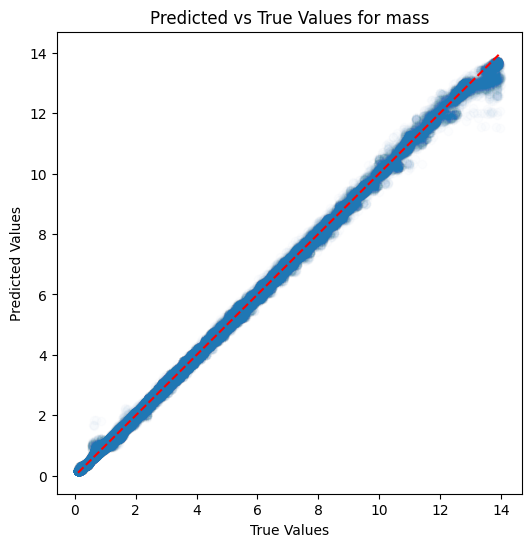

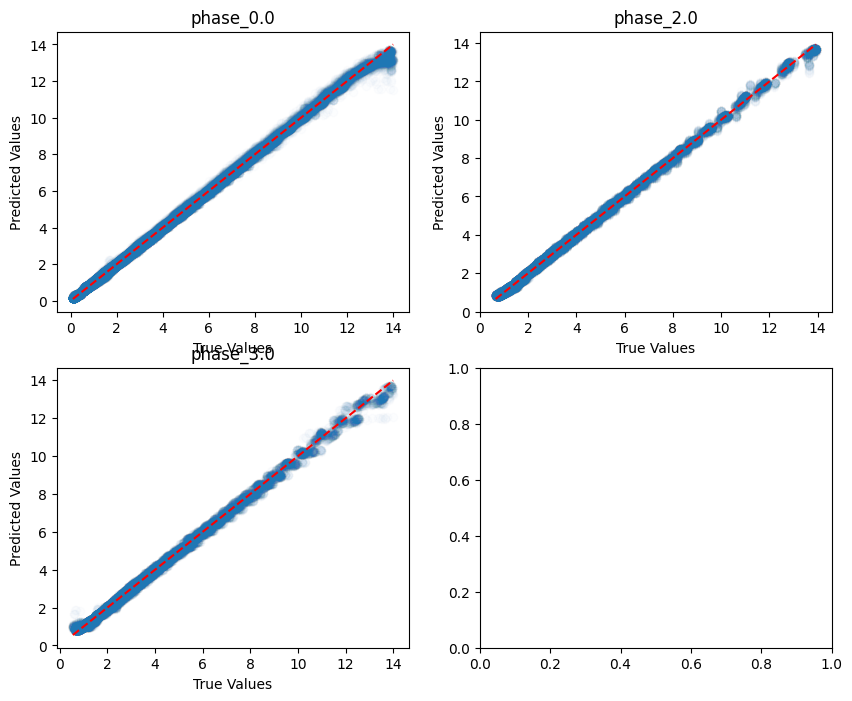

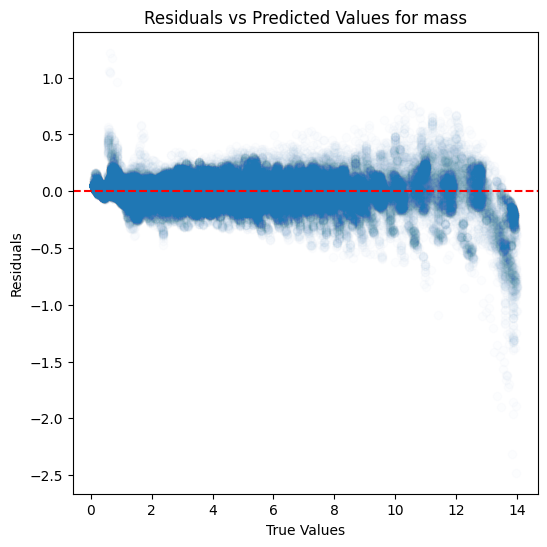

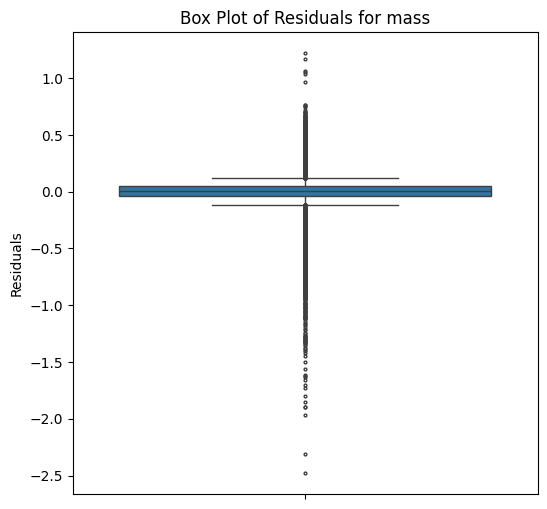

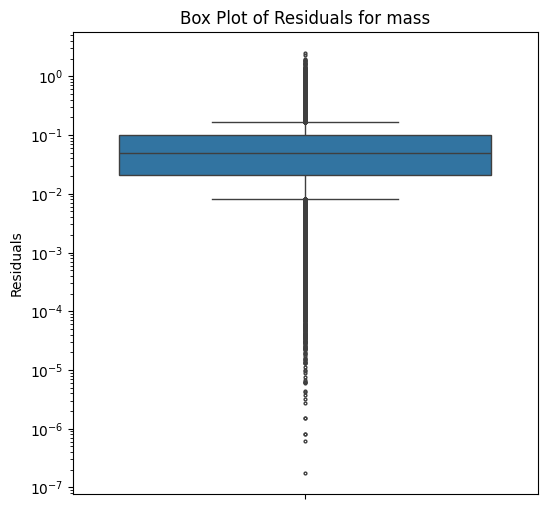

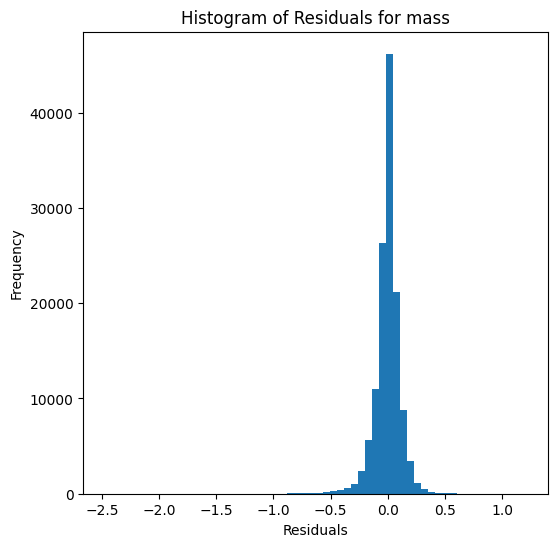

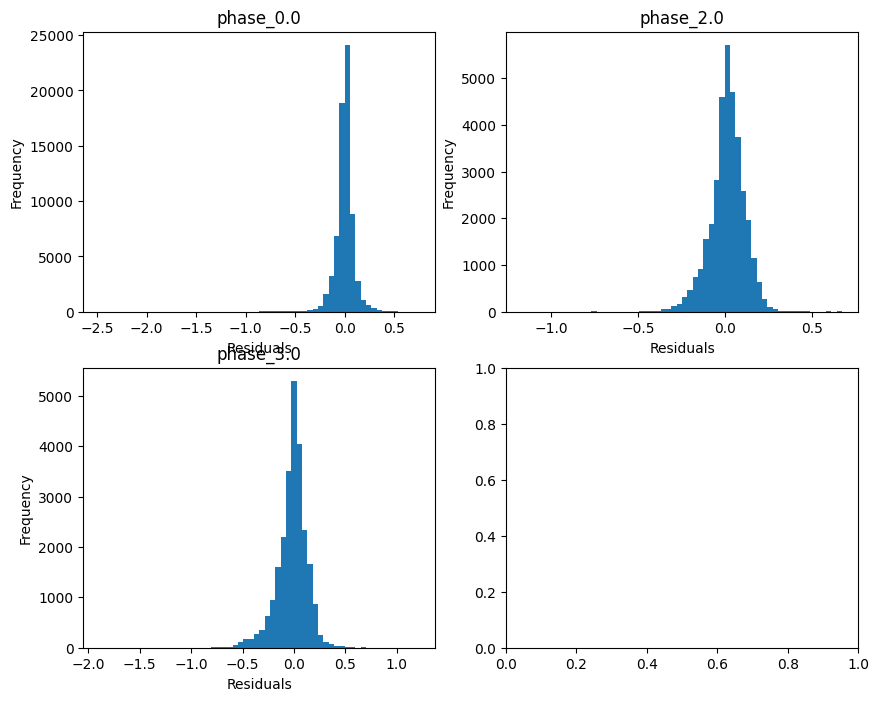

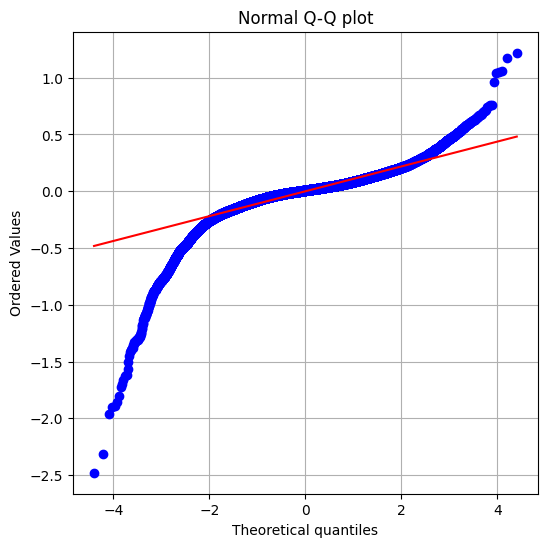

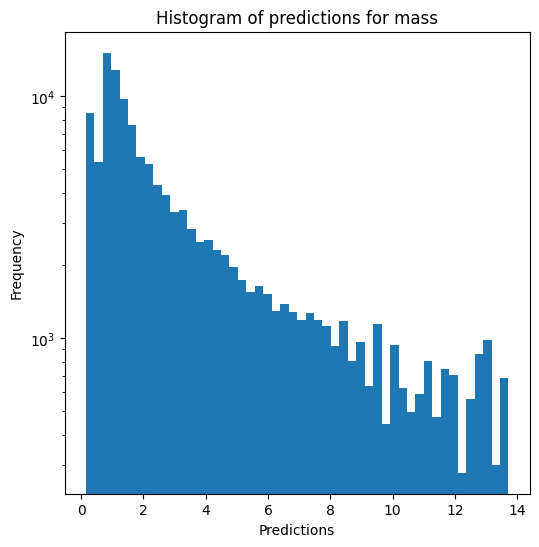

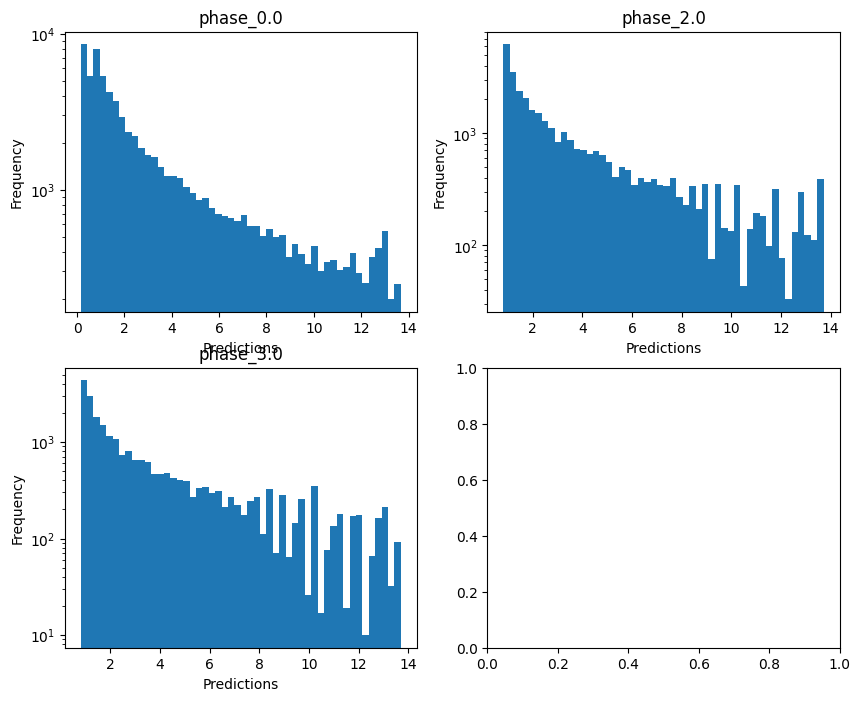


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 3.0827540579576227
  RVE :  0.9969183350609196
  RMSE :  0.02451430907751408
  MAE :  0.016372185568274373
  MedAE :  0.01140613615150593
  CORR :  0.9984668155511849
  MAX_ER :  0.19791222336994974
  Percentiles : 
    75th percentile :  0.02159676252094919
    90th percentile :  0.035206545025541824
    95th percentile :  0.046756664144572135
    99th percentile :  0.09589977047400013

radius results for the phase category with a value of 2.0
  value range :  0.0946930588223481 - 2.900376516729969
  RVE :  0.9954215414386258
  RMSE :  0.03167025427816513
  MAE :  0.024482966611969168
  MedAE :  0.01983954264095633
  CORR :  0.9977394662827819
  MAX_ER :  0.17873251549190905
  Percentiles : 
    75th percentile :  0.03460535342499049
    90th percentile :  0.05132989228674165
    95th percentile :  0.06311341426985413
    99th percentile :  0.09098374088570833

radius results for the phas

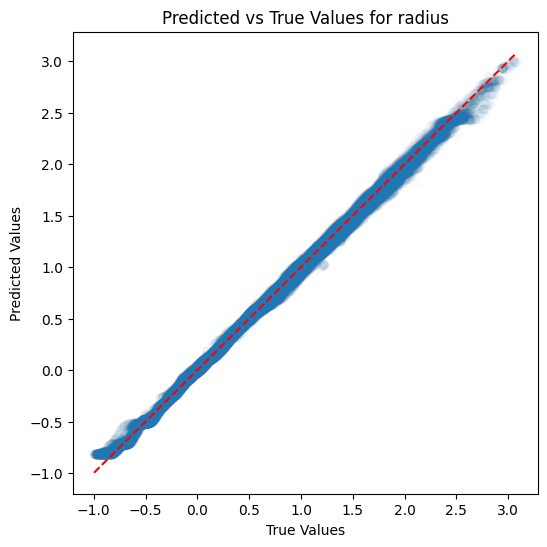

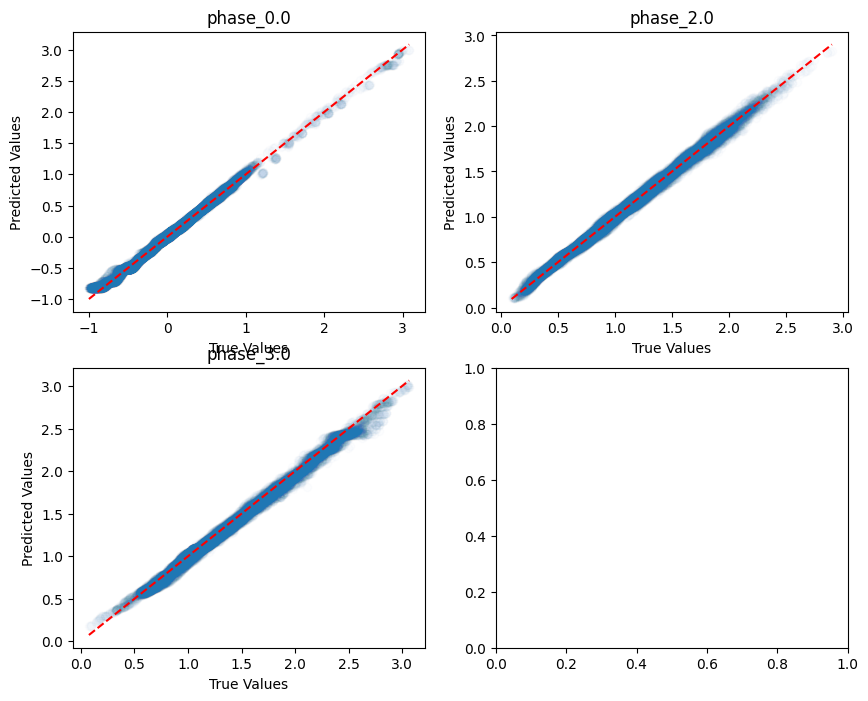

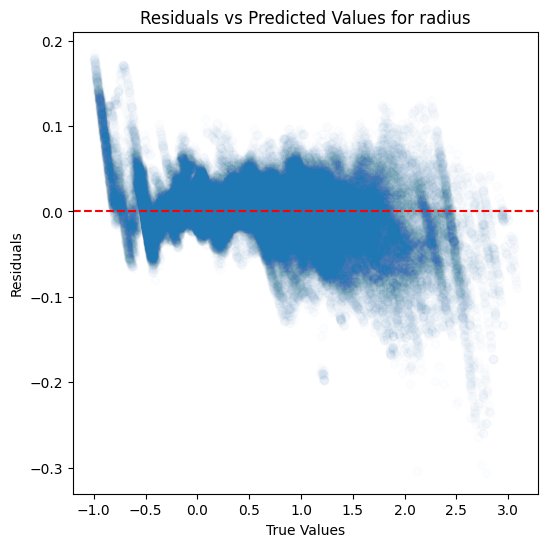

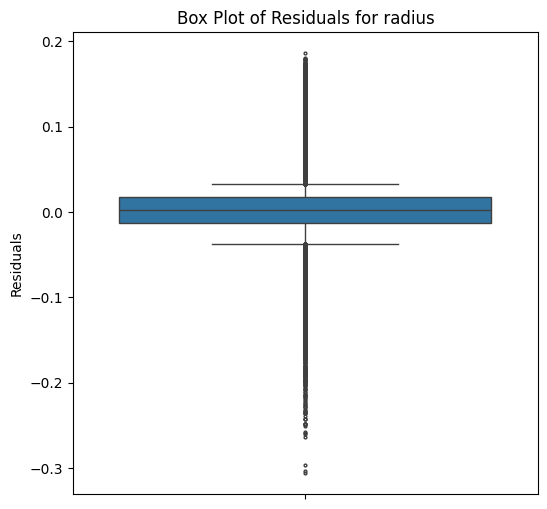

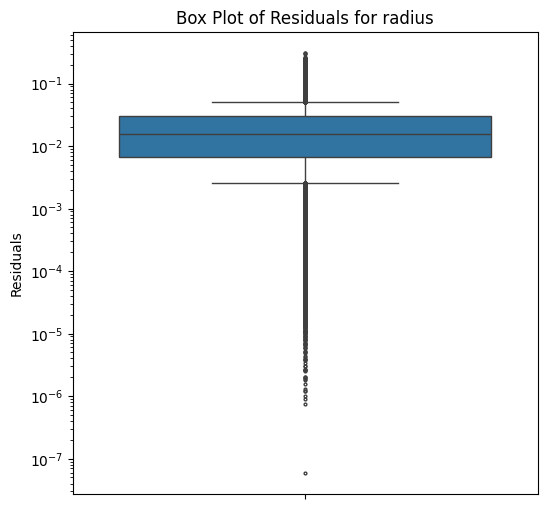

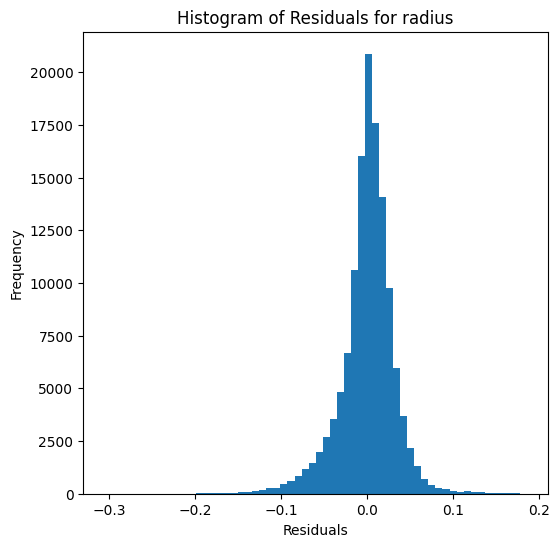

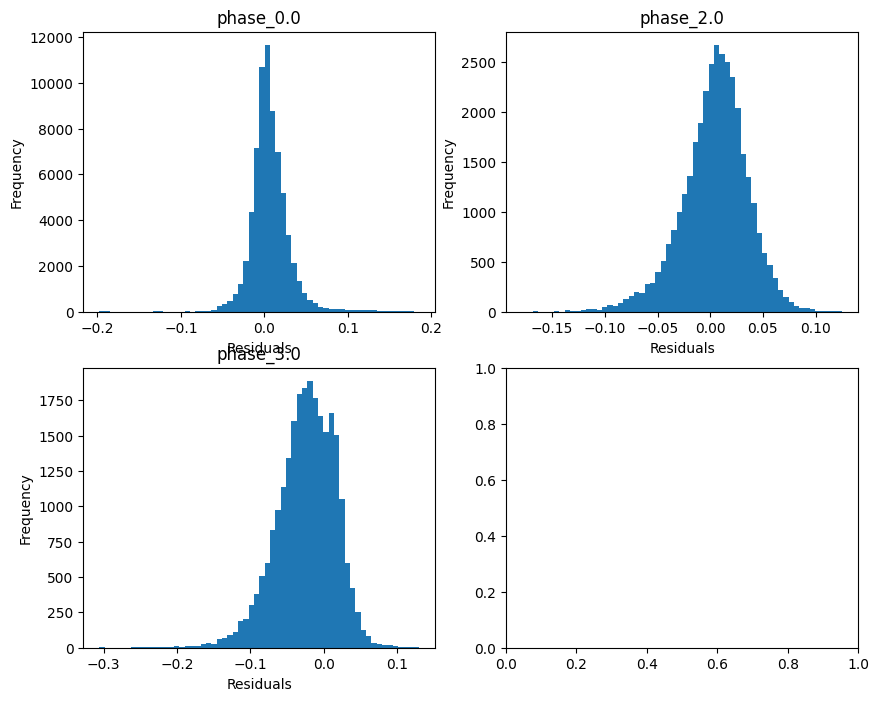

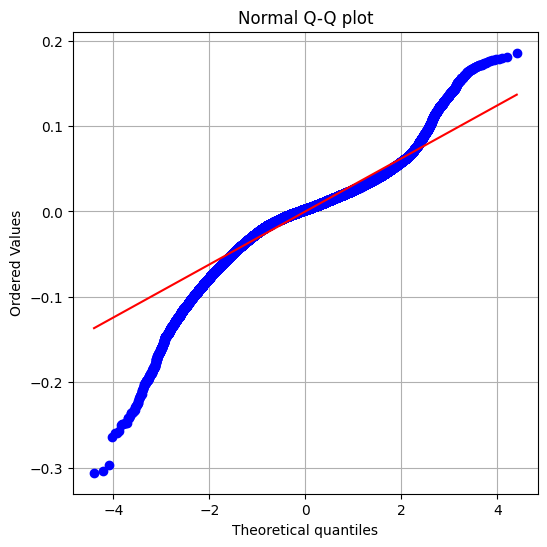

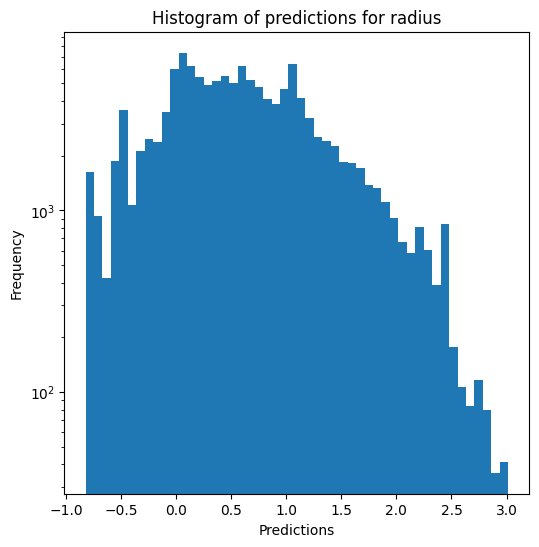

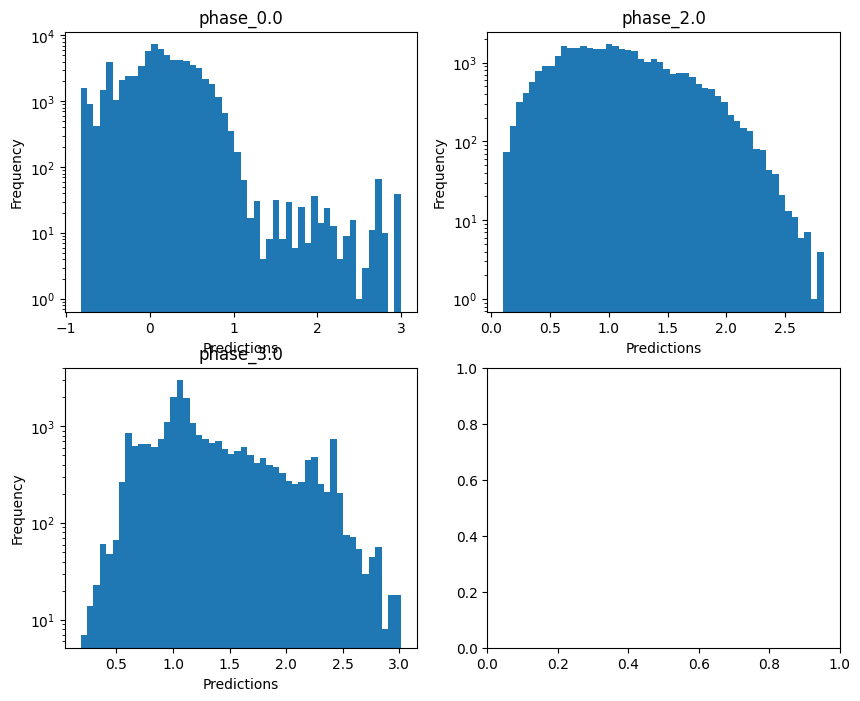

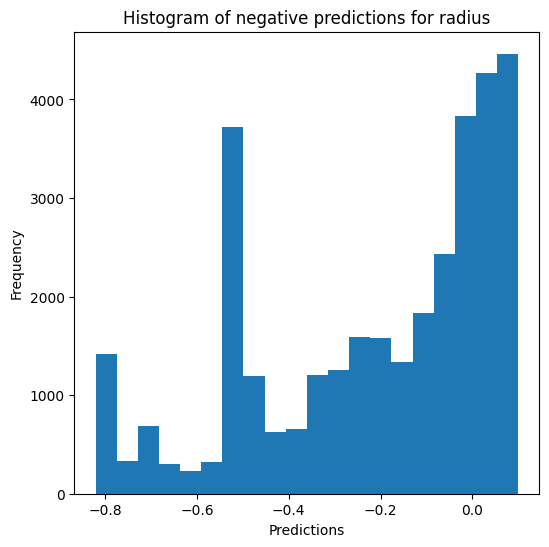

Saving predictions and results...


In [ ]:
best_params_RF = {'n_jobs':10, 'n_estimators': 1000, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': 600}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=False, show=True, **best_params_RF)

## Training the final model

In [9]:
X = np.append(X_train, X_ivs, 0)
y = np.append(y_train, y_ivs, 0)

print(X.shape)
print(y.shape)

(321696, 4)
(321696, 2)


### Final model with fine-tuned parameters

In [10]:
best_params_RF = {'n_jobs':10, 'n_estimators': 400, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None}

mdl = RandomForestRegressor(**best_params_RF)
mdl.fit(X, y)

,n_estimators,400
,criterion,'squared_error'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "Model_A_partial_PARSEC_RF_compress_0.pkl", compress=0)
# 7.3 GB, 1.82 GB après zip
# 11.8 secondes pour créé le fichier

['../../../../../../model/final_models/Model_A_partial_PARSEC_RF_compress_0.pkl']

In [ ]:
joblib.dump(mdl, pre_path + 'model/final_models/test_Model_A_partial_PARSEC_RF.pkl.z')
# 1.92 GB
# 1 minutes 30 pour créé le fichier

['../../../../../../model/final_models/test_Model_A_partial_PARSEC_RF.pkl.z']

In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "Model_A_partial_PARSEC_RF_compress_3.pkl", compress=3)
# 1.92 GB
# 1 minutes 30 pour créé le fichier

['../../../../../../model/final_models/Model_A_partial_PARSEC_RF_compress_3.pkl']